# Histogram Modeling — Progress Update

Figures for the `try6_hist_pow-xf_22km` product.  
Model: **HistogramMLP** (3-layer MLP, KL-div loss, 5-fold CV).  
Baseline: **Mean histogram** (per-trait average over training set).

In [24]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

RUN_DIR = PROJECT_ROOT / "models/try6_hist_pow-xf_22km/training/run_20260227_155511"
CV_DIR = RUN_DIR / "cv"
HPO_DIR = PROJECT_ROOT / "models/try6_hist_pow-xf_22km/hpo/hpo_20260227_120238"
ZARR_PATH = PROJECT_ROOT / "data/features/try6_hist_pow-xf_22km/xy_data/train.zarr"

# Load metrics
with open(CV_DIR / "cv_summary.json") as f:
    cv = json.load(f)
perf = pd.read_csv(CV_DIR / "performance_summary.csv")

# Dark slide theme
sns.set_theme(style="dark", rc={
    "figure.dpi": 300,
    "figure.facecolor": "black",
    "axes.facecolor": "black",
    "savefig.facecolor": "black",
    "savefig.dpi": 300,
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.titlecolor": "white",
    "axes.edgecolor": "#444444",
    "grid.color": "#333333",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#555555",
    "legend.labelcolor": "white",
})

# Two-color palette: cyan for model, magenta/pink for baseline
C_MODEL = "#00e5ff"   # bright cyan
C_BASE = "#ff4081"    # bright pink/magenta
C_ACCENT = "#76ff03"  # lime green for annotations/highlights
C_LINE = "#888888"    # muted gray for connectors

print(f"Loaded {len(perf)} traits, {cv['n_folds']} folds")

Loaded 31 traits, 5 folds


## Figure 1: Model vs. Baseline — Overall Metrics Summary

Grouped bar chart comparing model and baseline across 4 distribution metrics (averaged over 31 traits, 5-fold CV).

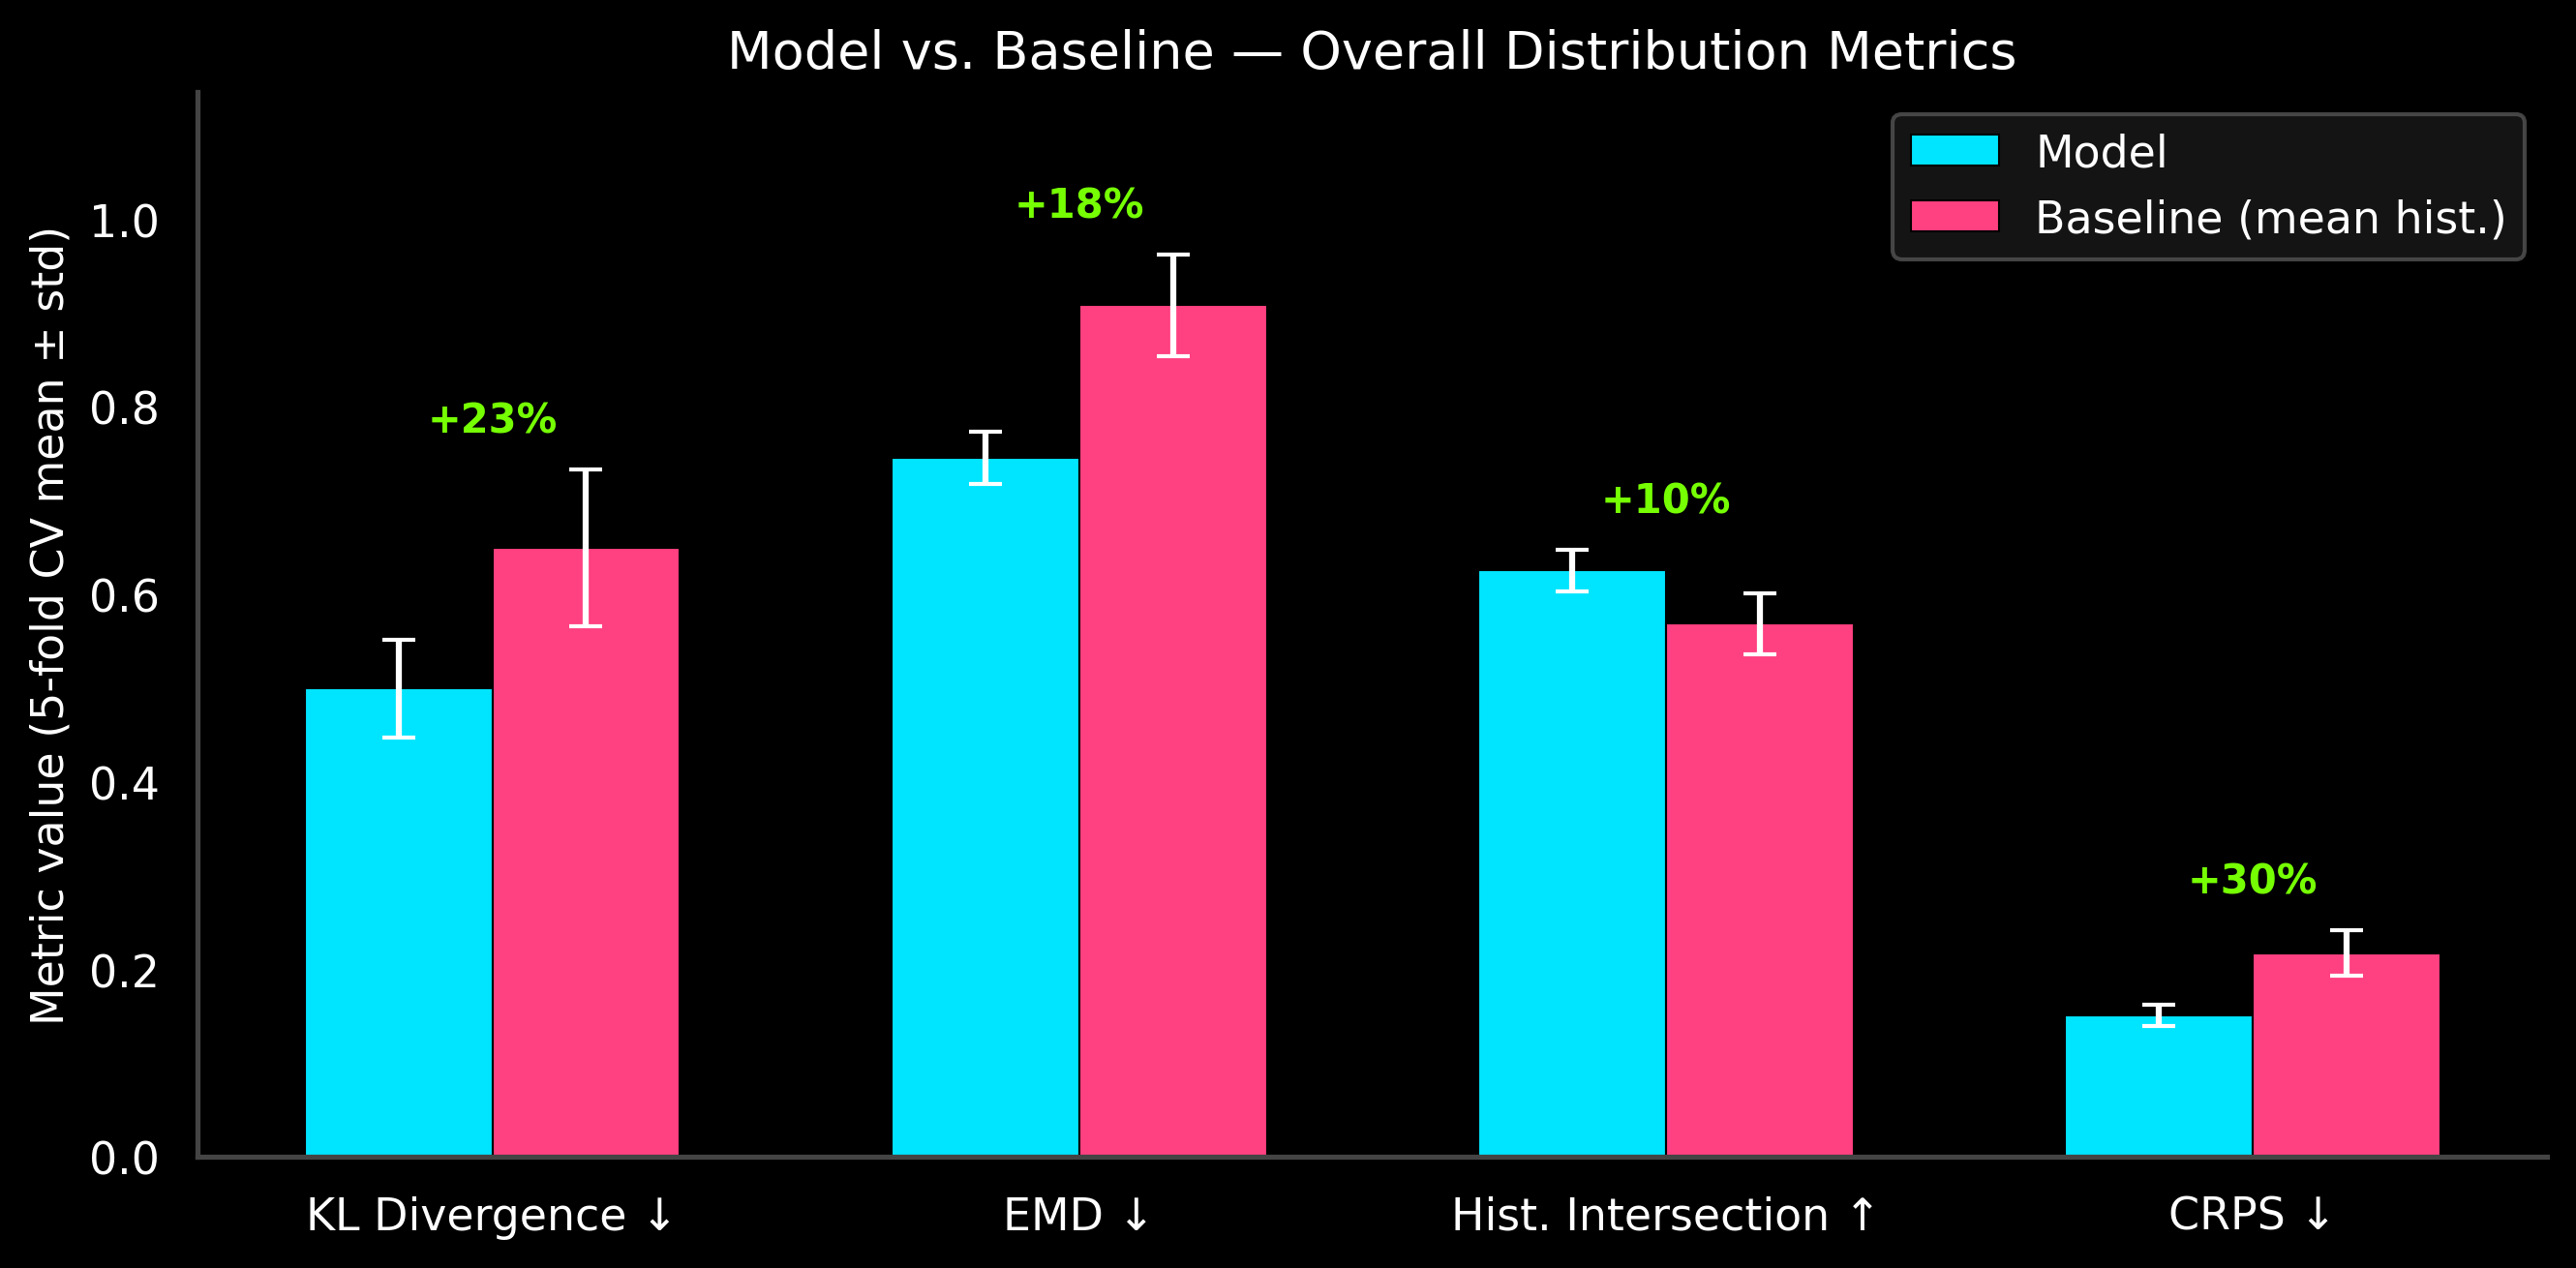

In [25]:
metrics = ["KL Divergence ↓", "EMD ↓", "Hist. Intersection ↑", "CRPS ↓"]
model_vals = [cv["kl_divergence_mean"], cv["emd_mean"], cv["histogram_intersection_mean"], cv["crps_mean"]]
model_stds = [cv["kl_divergence_std"], cv["emd_std"], cv["histogram_intersection_std"], cv["crps_std"]]
base_vals = [cv["baseline_kl_divergence_mean"], cv["baseline_emd_mean"],
             cv["baseline_histogram_intersection_mean"], cv["baseline_crps_mean"]]
base_stds = [cv["baseline_kl_divergence_std"], cv["baseline_emd_std"],
             cv["baseline_histogram_intersection_std"], cv["baseline_crps_std"]]

# Compute relative improvement
improvements = []
for i, m in enumerate(metrics):
    if "↑" in m:
        pct = (model_vals[i] - base_vals[i]) / base_vals[i] * 100
    else:
        pct = (base_vals[i] - model_vals[i]) / base_vals[i] * 100
    improvements.append(pct)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(metrics))
w = 0.32

bars_m = ax.bar(x - w / 2, model_vals, w, yerr=model_stds, label="Model", color=C_MODEL,
                capsize=4, edgecolor="black", linewidth=0.5, error_kw=dict(ecolor="white", capthick=1))
bars_b = ax.bar(x + w / 2, base_vals, w, yerr=base_stds, label="Baseline (mean hist.)", color=C_BASE,
                capsize=4, edgecolor="black", linewidth=0.5, error_kw=dict(ecolor="white", capthick=1))

# Annotate improvement
for i, pct in enumerate(improvements):
    y_top = max(model_vals[i] + model_stds[i], base_vals[i] + base_stds[i]) + 0.03
    sign = "+" if pct > 0 else ""
    ax.text(x[i], y_top, f"{sign}{pct:.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold",
            color=C_ACCENT)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Metric value (5-fold CV mean ± std)")
ax.set_title("Model vs. Baseline — Overall Distribution Metrics")
ax.legend(loc="upper right")
ax.set_ylim(0, max(max(model_vals), max(base_vals)) * 1.25)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Figure 2: Per-Trait R² — Model vs. Baseline (Lollipop Plot)

Horizontal lollipop chart showing model R² (blue) vs. baseline R² (orange) for all 31 traits, sorted by improvement (Δ R²). The model achieves positive R² on all traits; the mean-histogram baseline is negative everywhere.

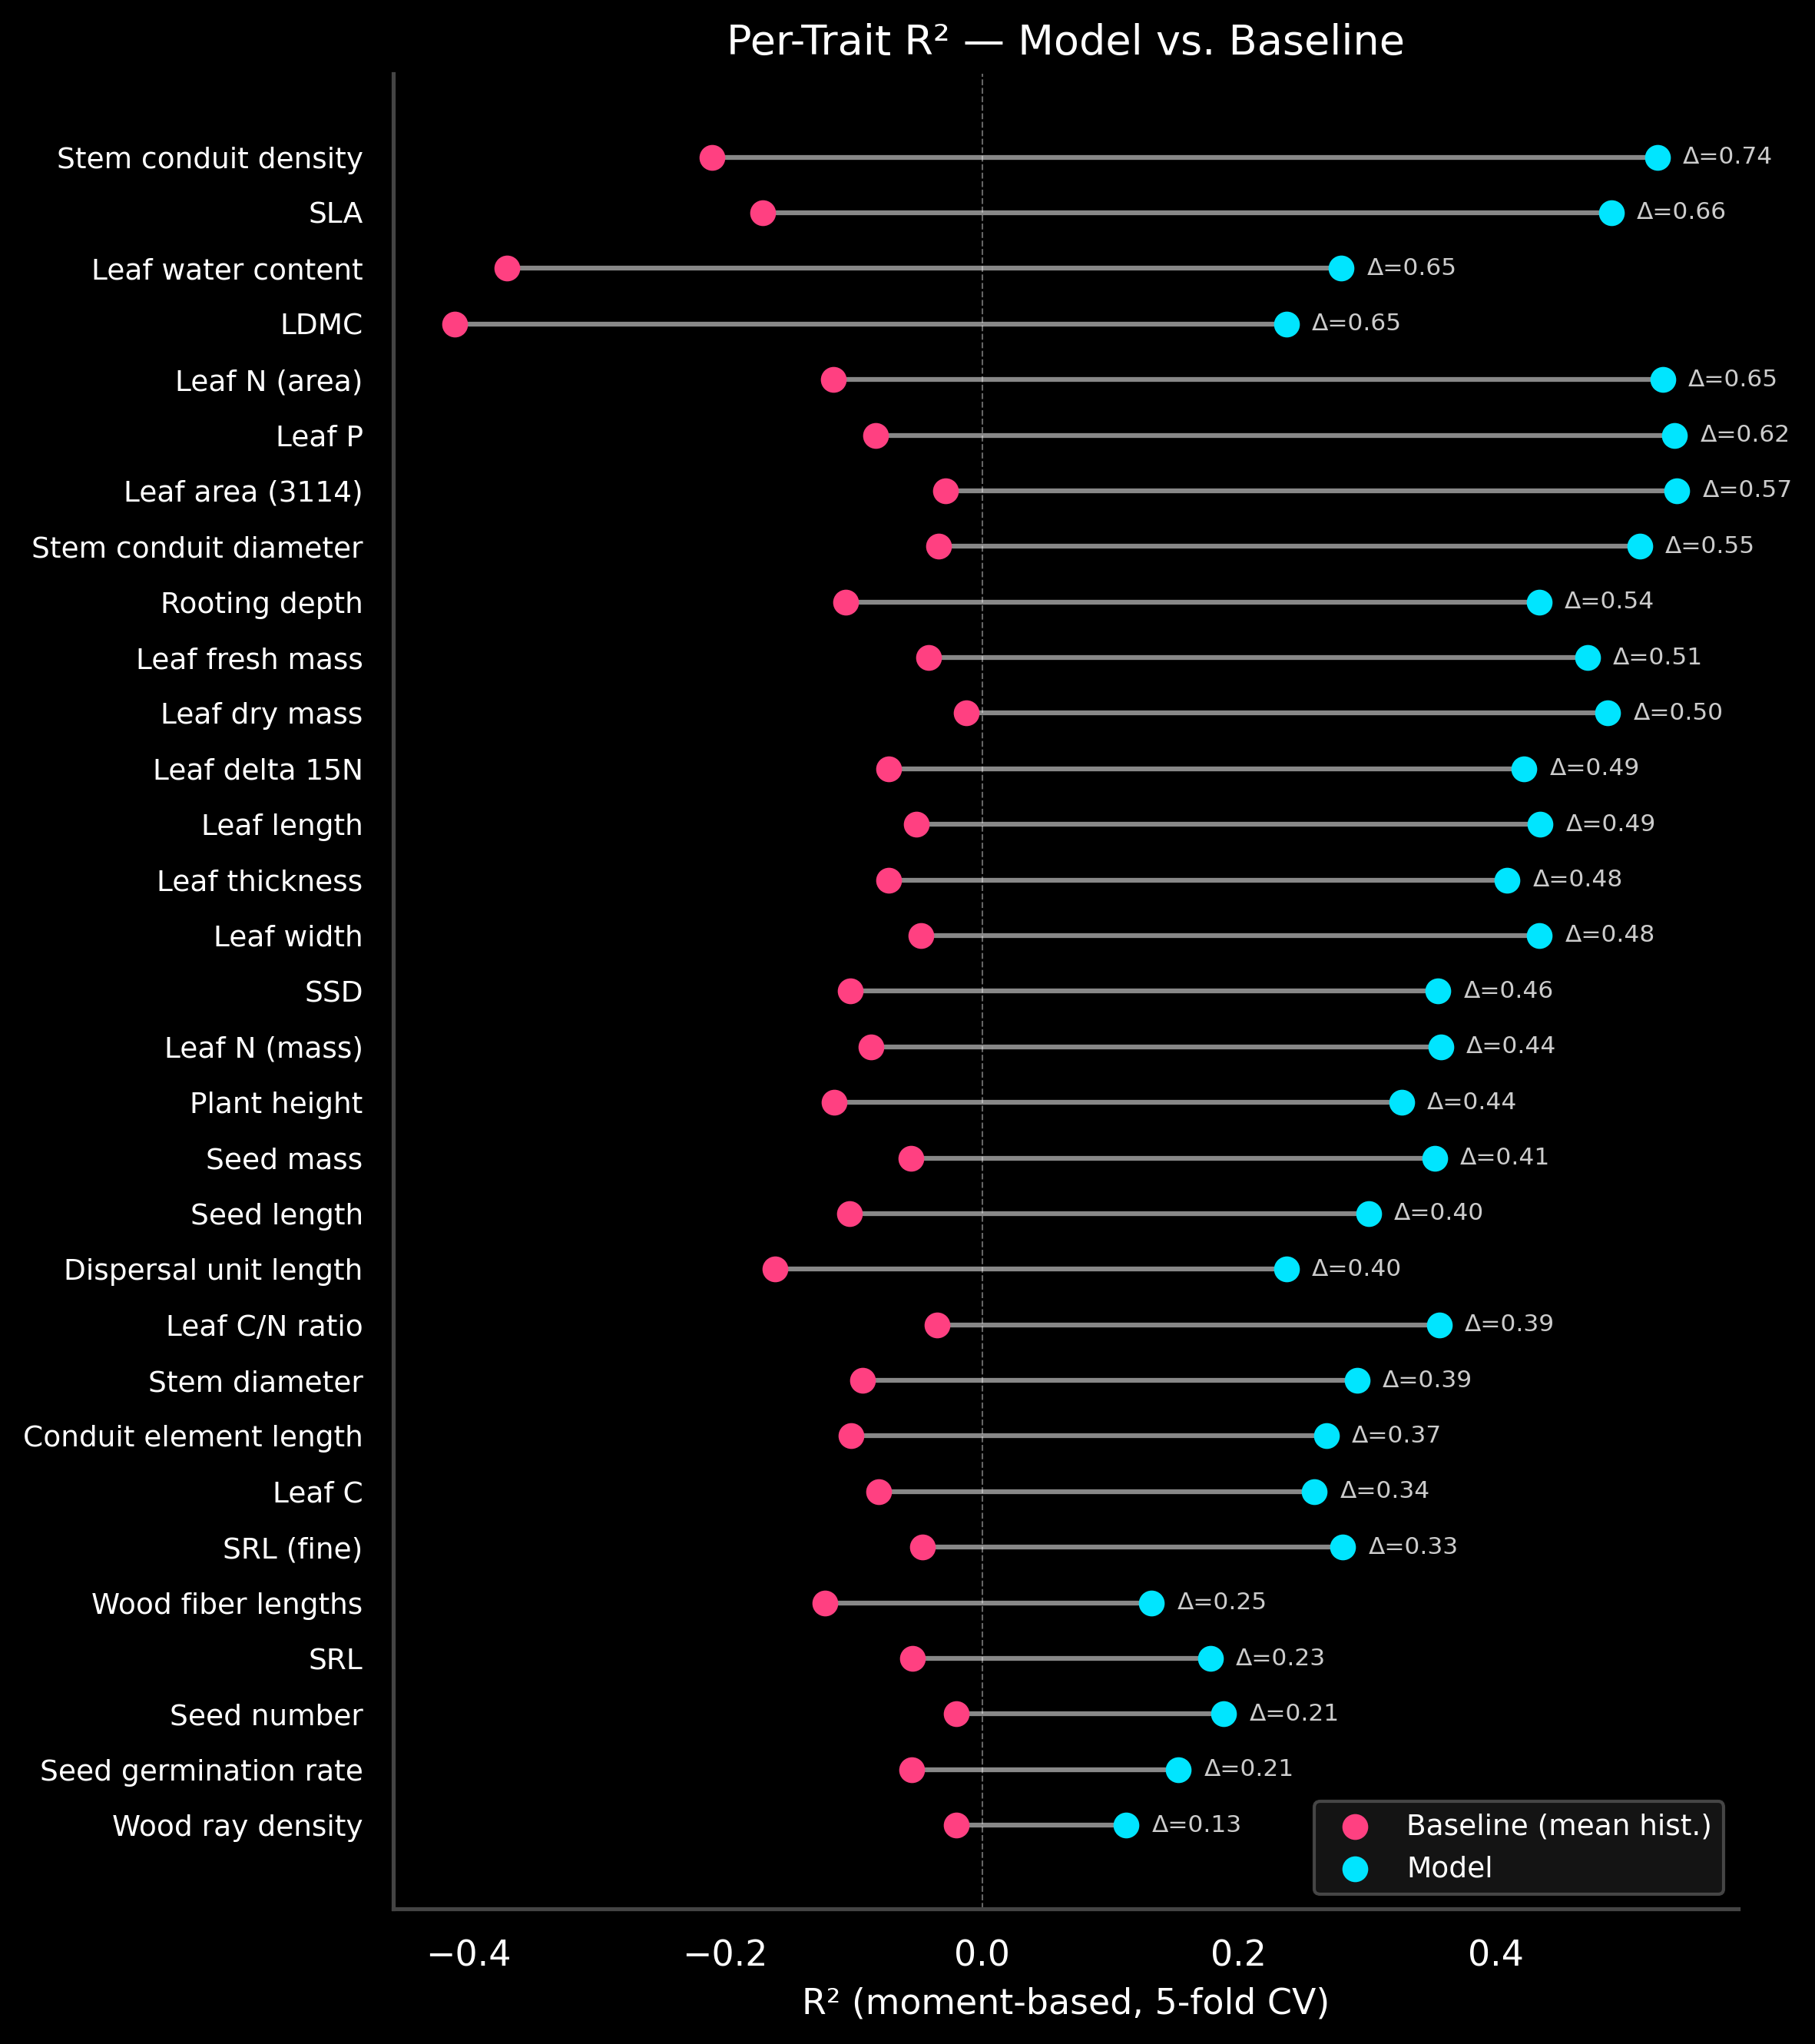

In [26]:
df = perf.sort_values("delta_R2", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 9))
y = np.arange(len(df))

# Draw connecting lines
for i, row in df.iterrows():
    ax.plot([row["baseline_R2"], row["model_R2"]], [i, i], color=C_LINE, linewidth=1.5, zorder=1)

ax.scatter(df["baseline_R2"], y, color=C_BASE, s=50, zorder=2, label="Baseline (mean hist.)")
ax.scatter(df["model_R2"], y, color=C_MODEL, s=50, zorder=2, label="Model")

# Annotate delta R² on the right
for i, row in df.iterrows():
    ax.text(row["model_R2"] + 0.02, i, f"Δ={row['delta_R2']:.2f}", va="center", fontsize=7.5, color="#cccccc")

ax.axvline(0, color="white", linewidth=0.5, linestyle="--", alpha=0.4)
ax.set_yticks(y)
ax.set_yticklabels(df["short_name"], fontsize=9)
ax.set_xlabel("R² (moment-based, 5-fold CV)")
ax.set_title("Per-Trait R² — Model vs. Baseline")
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Figure 3: Example Predicted Histograms vs. Targets

2×3 panel of predicted (blue) vs. target (orange) histograms for selected validation cells across well-predicted traits. Uses fold 0 validation set.

In [27]:
import torch
import zarr
from models.histogram_mlp.model import HistogramMLP

# Load data
root = zarr.open_group(str(ZARR_PATH), mode="r")
X_raw = np.asarray(root["X"])
Y_hist = np.asarray(root["Y_hist"])
Y_mask = np.asarray(root["Y_mask"])
source = np.asarray(root["source"])
folds = np.asarray(root["folds"])
bin_edges = np.asarray(root["bin_edges"])
trait_names = list(root.attrs.get("trait_names", []))

# Load feature stats for preprocessing
stats = np.load(RUN_DIR / "feature_stats.npz")

# Preprocess features using saved stats
X = X_raw.copy().astype(np.float32)
X[X == 32767.0] = np.nan
X[X == -32767.0] = np.nan
for j in range(X.shape[1]):
    X[np.isnan(X[:, j]), j] = stats["median"][j]
X = (X - stats["mean"]) / stats["std"]

# Fold 0 val indices: sPlot cells (source==1) in fold 0
val_mask = (folds == 0) & (source == 1)
val_idx = np.where(val_mask)[0]

# Load fold 0 model
model = HistogramMLP(n_features=X.shape[1], n_traits=len(trait_names), n_bins=20,
                     hidden_dims=[1024, 768, 1024], dropout=0.35)
model.load_state_dict(torch.load(CV_DIR / "fold_0/best_model.pt", map_location="cpu", weights_only=True))
model.eval()

# Predict on validation set
with torch.no_grad():
    X_val = torch.from_numpy(X[val_idx]).float()
    log_pred = model(X_val)
    pred_probs = torch.exp(log_pred).numpy()  # (N_val, 31, 20)

print(f"Validation cells: {len(val_idx)}, predictions: {pred_probs.shape}")

Validation cells: 4554, predictions: (4554, 31, 20)


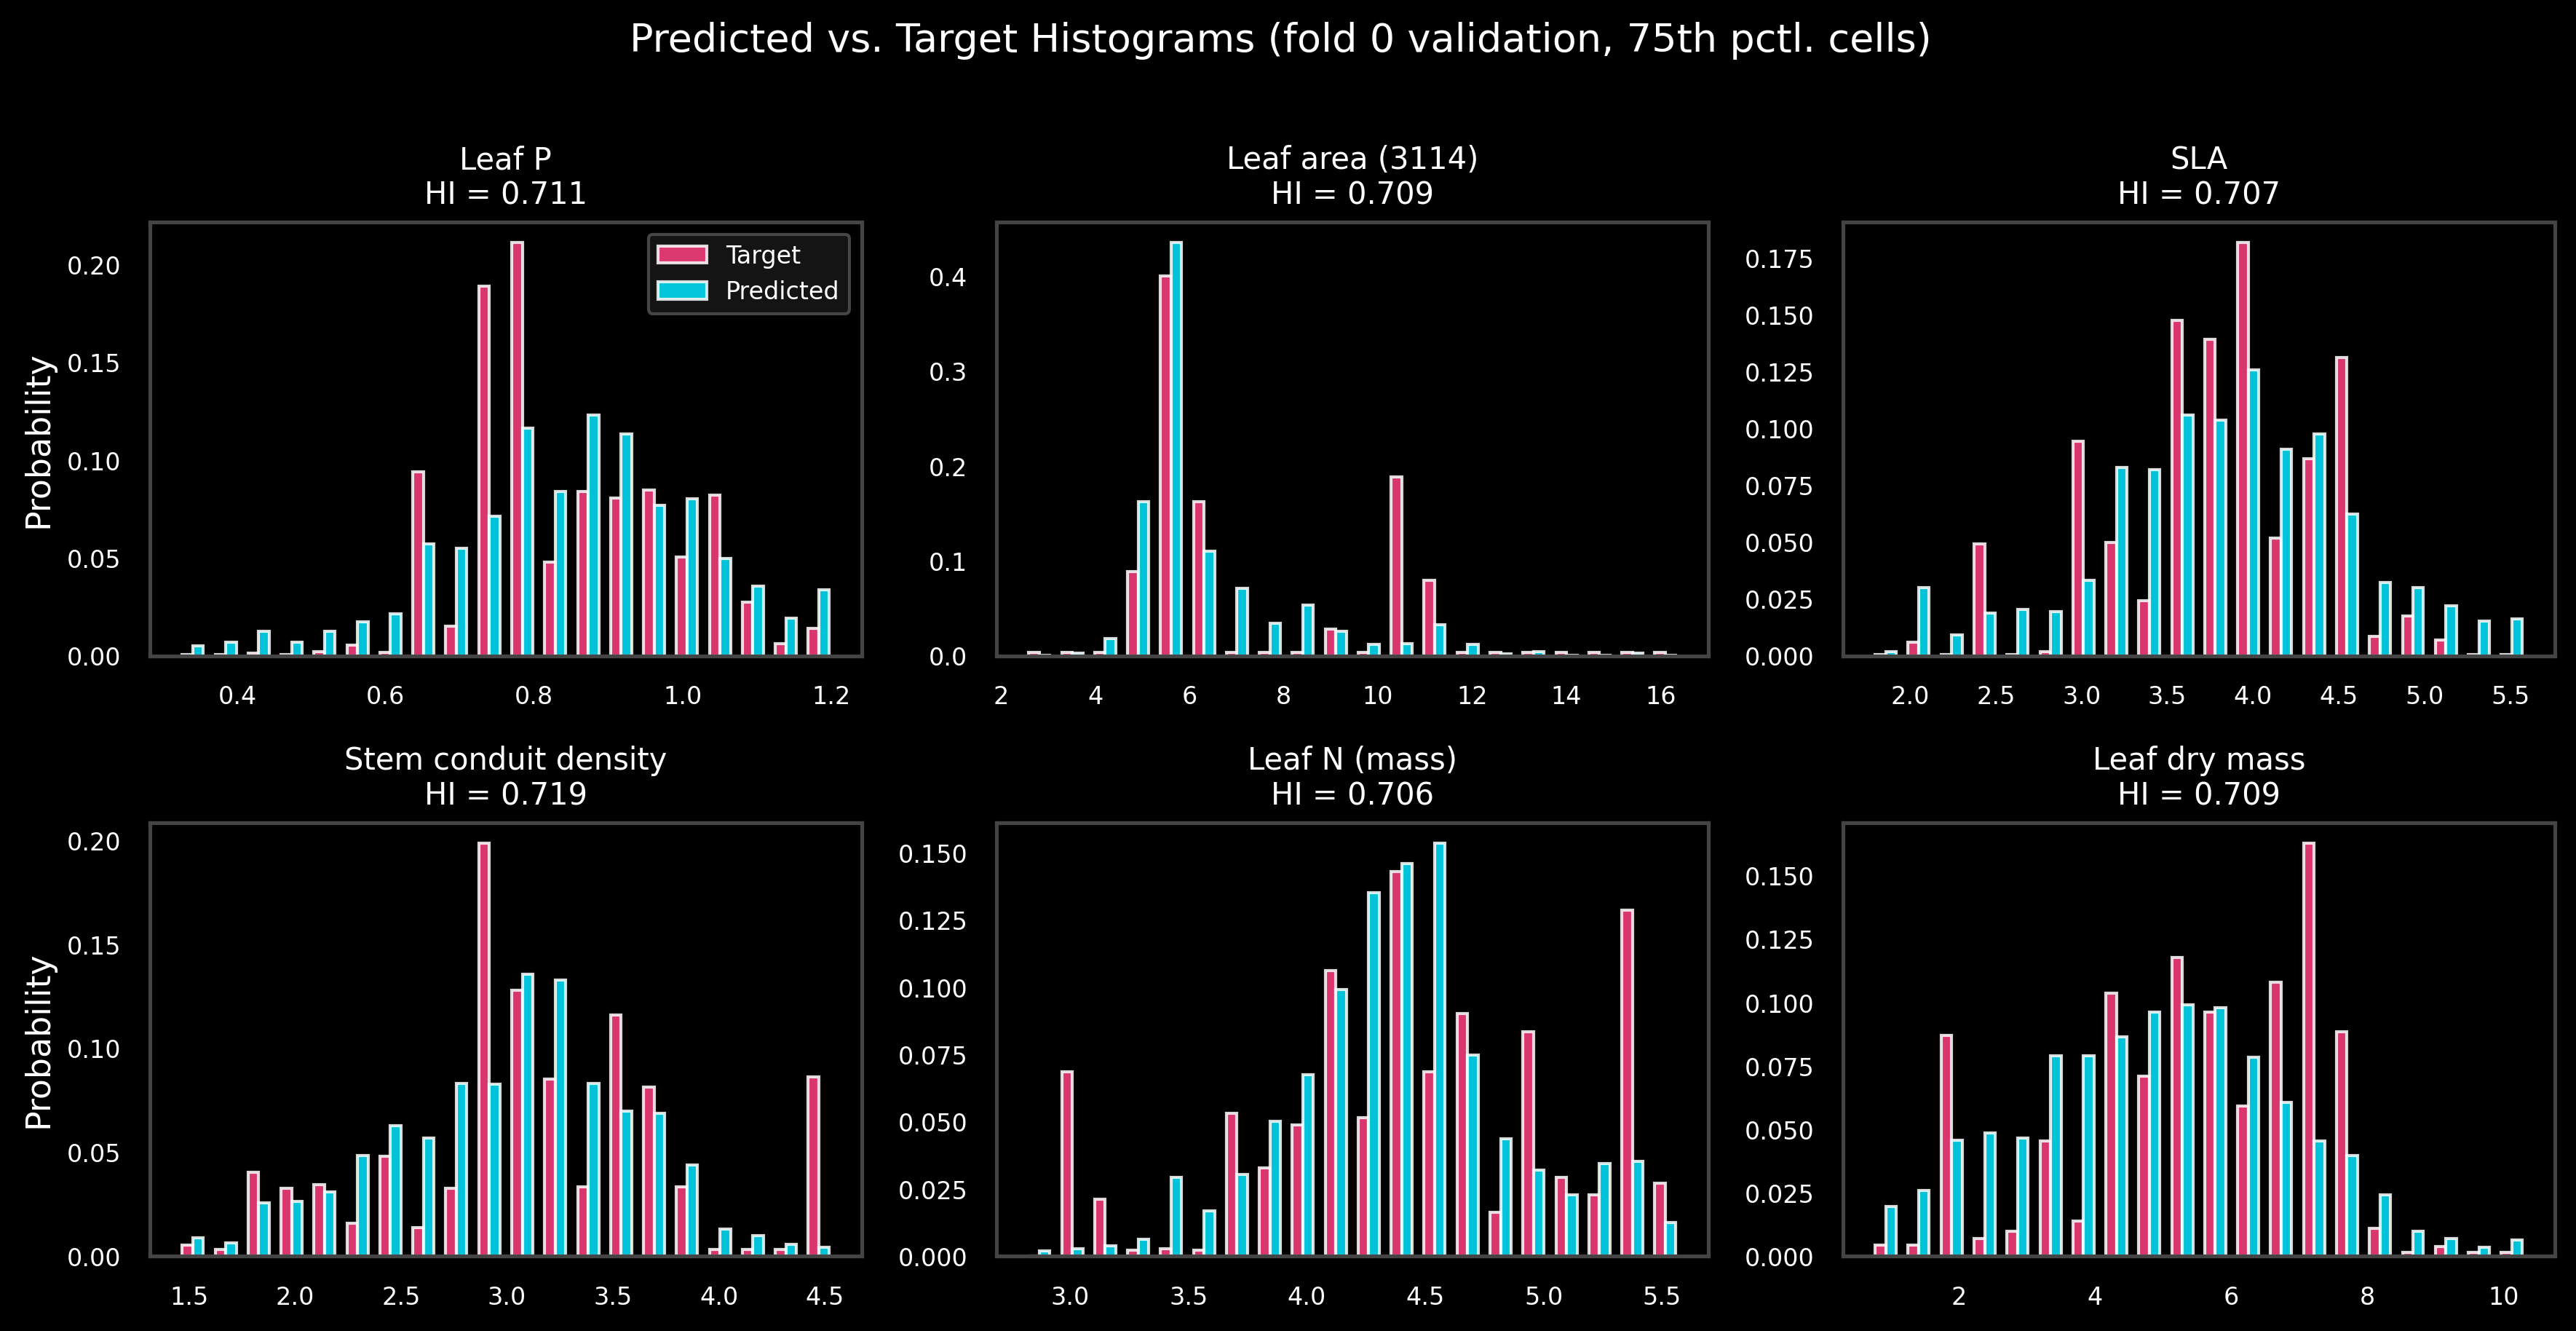

In [28]:
# Select 6 well-predicted traits and pick representative cells
show_traits = ["Leaf P", "Leaf area (3114)", "SLA", "Stem conduit density", "Leaf N (mass)", "Leaf dry mass"]
trait_id_map = dict(zip(perf["short_name"], perf["trait_id"]))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, trait_name in zip(axes.flat, show_traits):
    tid = trait_id_map[trait_name]
    t_idx = trait_names.index(tid)

    # Find cells with valid data for this trait
    valid = Y_mask[val_idx, t_idx] > 0
    valid_pos = np.where(valid)[0]

    # Pick cell with best histogram intersection for a visually compelling example
    hi_scores = []
    for vi in valid_pos:
        pred = pred_probs[vi, t_idx]
        target = Y_hist[val_idx[vi], t_idx]
        hi_scores.append(np.sum(np.minimum(pred, target)))
    # Pick the cell near the 75th percentile (good but not cherry-picked)
    rank_idx = valid_pos[np.argsort(hi_scores)[int(len(hi_scores) * 0.75)]]

    pred = pred_probs[rank_idx, t_idx]
    target = Y_hist[val_idx[rank_idx], t_idx]
    edges = bin_edges[t_idx]
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = (edges[1] - edges[0]) * 0.8

    ax.bar(centers - width * 0.2, target, width * 0.4, label="Target", color=C_BASE, alpha=0.85)
    ax.bar(centers + width * 0.2, pred, width * 0.4, label="Predicted", color=C_MODEL, alpha=0.85)
    hi = np.sum(np.minimum(pred, target))
    ax.set_title(f"{trait_name}\nHI = {hi:.3f}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=8)

axes[0, 0].set_ylabel("Probability")
axes[1, 0].set_ylabel("Probability")
axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle("Predicted vs. Target Histograms (fold 0 validation, 75th pctl. cells)", fontsize=13, y=1.01, color="white")
fig.tight_layout()
plt.show()

## Figure 4: HPO Convergence

Scatter plot of validation loss across Optuna trials, showing convergence toward the best trial. Colored by batch size to highlight which search regions worked best.

/tmp/ipykernel_313190/4220111432.py:4: FutureWarning: JournalFileStorage has been deprecated in v4.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.0.0. Use :class:`~optuna.storages.journal.JournalFileBackend` instead.
  storage = JournalStorage(JournalFileStorage(str(HPO_DIR / "journal.log")))


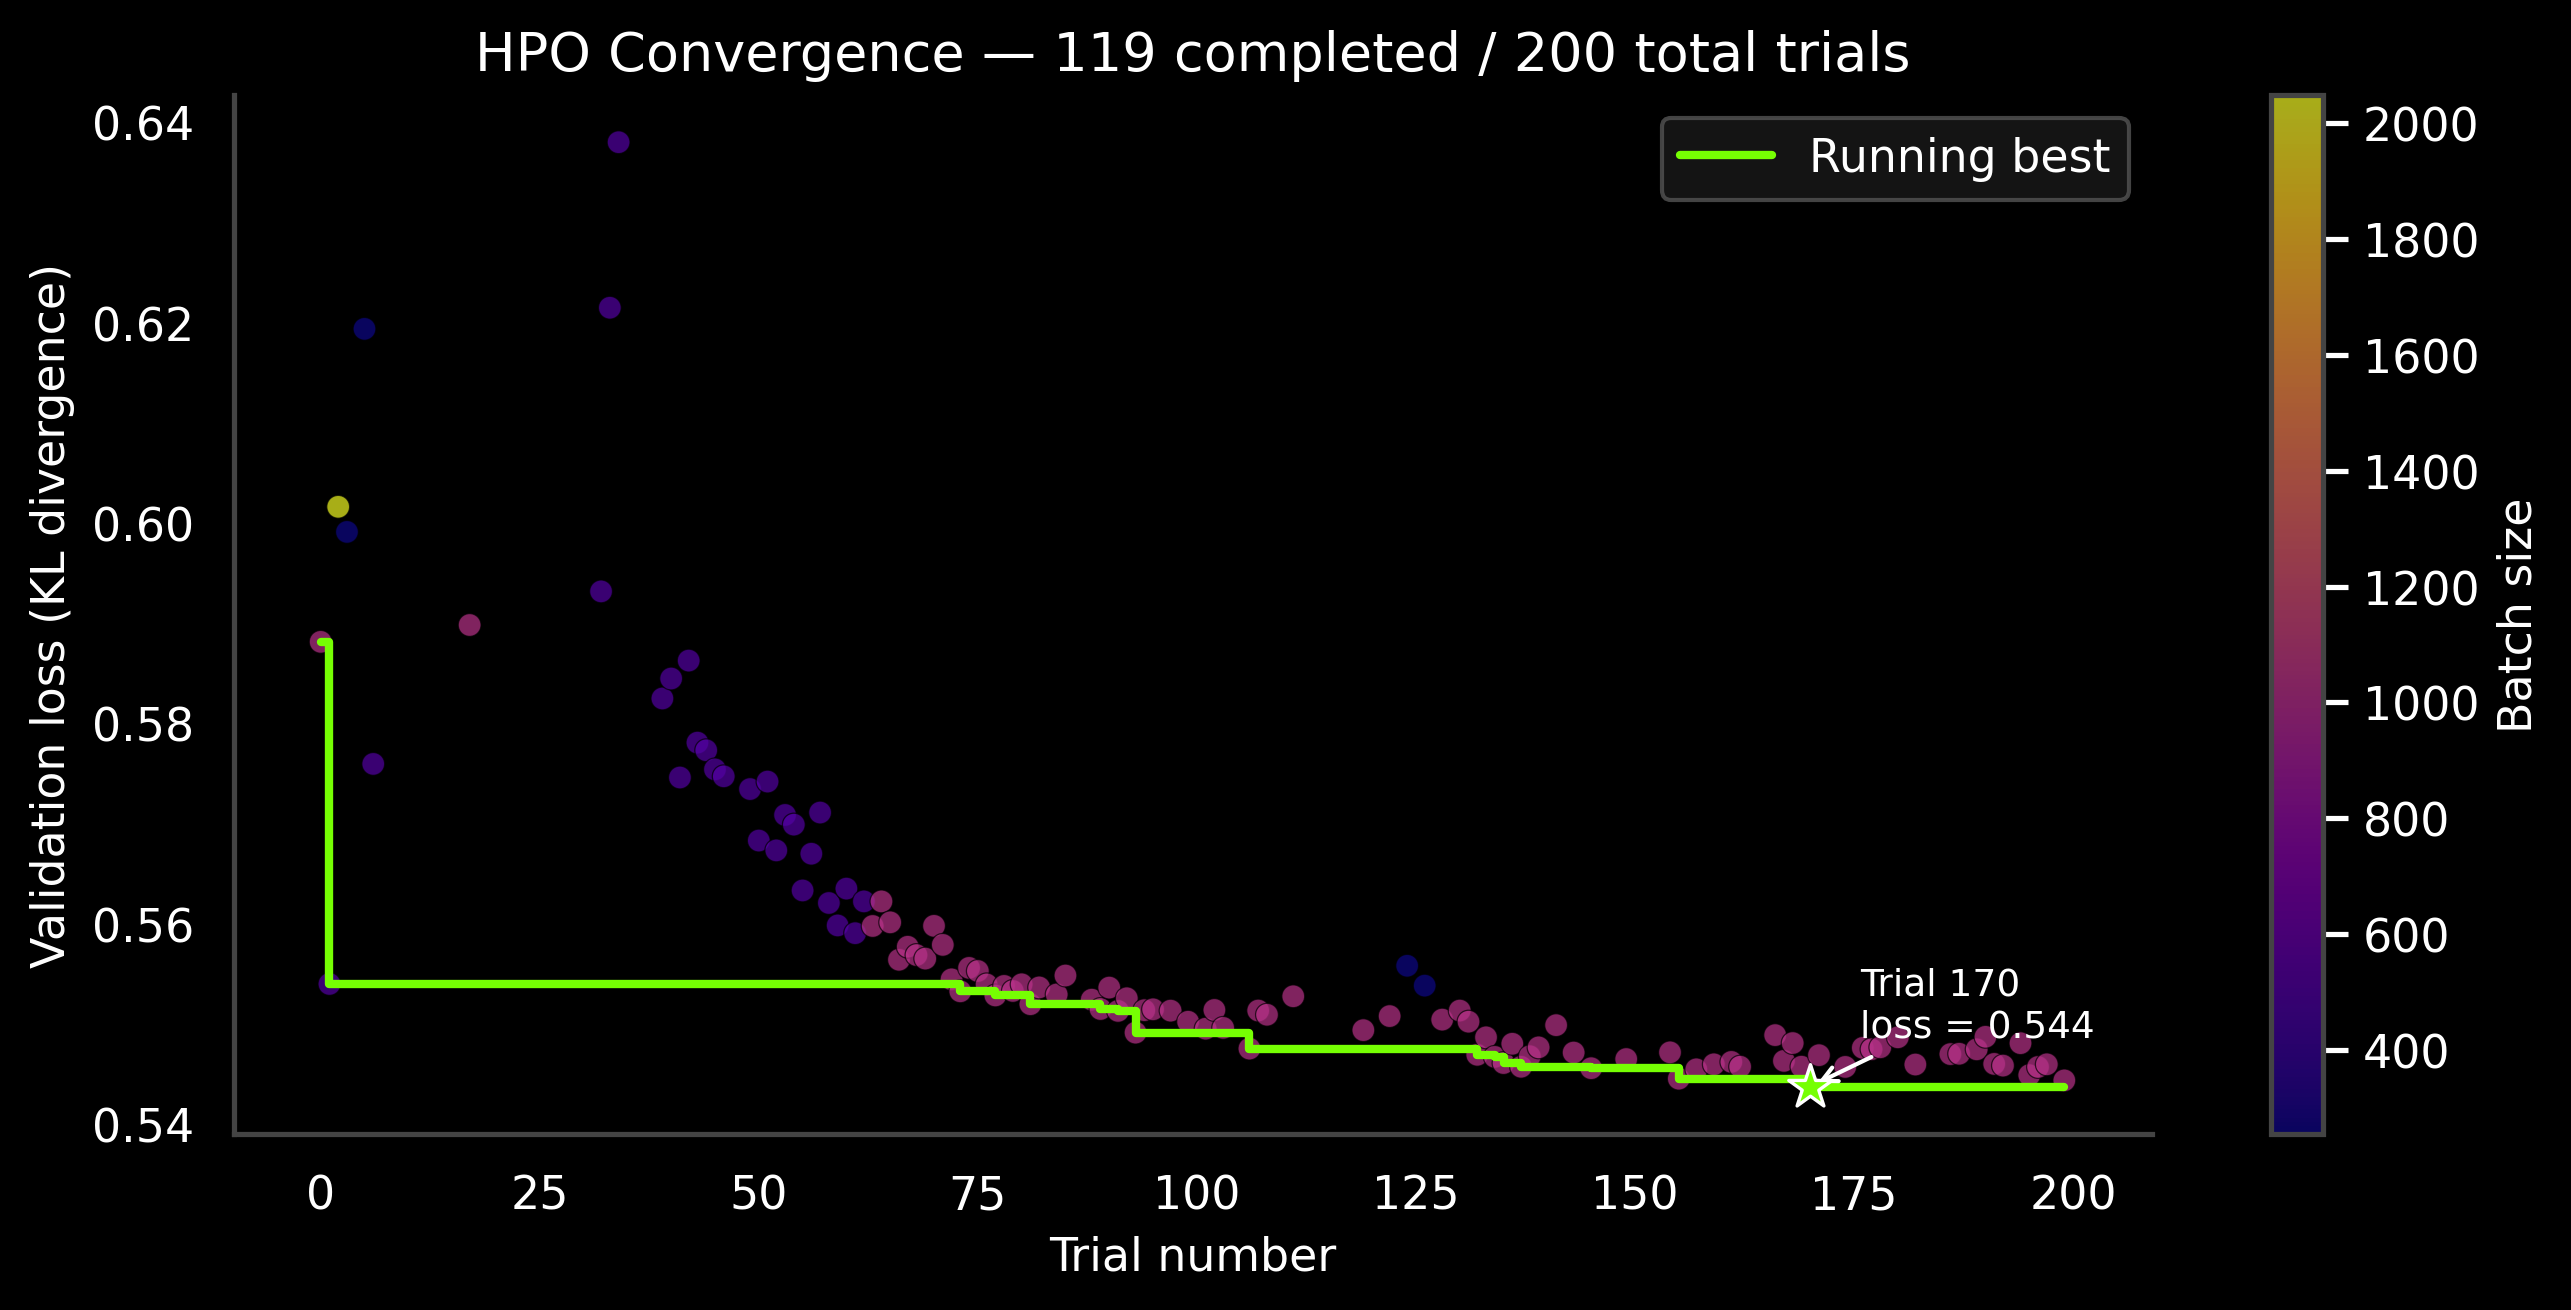

Hyperparameter,Value
Hidden layers,3
Hidden dim 1,1024
Hidden dim 2,768
Hidden dim 3,1024
Dropout,0.3500
Learning rate,5.13e-04
Weight decay,1.73e-05
Batch size,1024
GBIF weight factor,0.5039
Best val loss,0.5437


In [29]:
import optuna
from optuna.storages import JournalStorage, JournalFileStorage

storage = JournalStorage(JournalFileStorage(str(HPO_DIR / "journal.log")))
study = optuna.load_study(study_name="hpo_20260227_120238", storage=storage)

# Extract completed trials
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number for t in completed]
val_losses = [t.value for t in completed]
batch_sizes = [t.params.get("batch_size", np.nan) for t in completed]

# Running best
sorted_trials = sorted(zip(trial_nums, val_losses), key=lambda x: x[0])
running_best = []
best_so_far = float("inf")
for tn, vl in sorted_trials:
    best_so_far = min(best_so_far, vl)
    running_best.append((tn, best_so_far))

fig, ax = plt.subplots(figsize=(9, 4.5))
sc = ax.scatter(trial_nums, val_losses, c=batch_sizes, cmap="plasma", s=30, alpha=0.7,
                edgecolors="black", linewidth=0.3)
rb_x, rb_y = zip(*running_best)
ax.step(rb_x, rb_y, color=C_ACCENT, linewidth=2, label="Running best", where="post")

# Mark best trial
best = study.best_trial
ax.scatter([best.number], [best.value], color=C_ACCENT, s=120, zorder=5, marker="*",
           edgecolors="white", linewidth=0.8)
ax.annotate(f"Trial {best.number}\nloss = {best.value:.3f}", (best.number, best.value),
            textcoords="offset points", xytext=(12, 12), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="white"), color="white")

cbar = fig.colorbar(sc, ax=ax, label="Batch size")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.ax.yaxis.label.set_color("white")

ax.set_xlabel("Trial number")
ax.set_ylabel("Validation loss (KL divergence)")
ax.set_title(f"HPO Convergence — {len(completed)} completed / {len(study.trials)} total trials")
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

# Best hyperparameters as a copy-pasteable table
from IPython.display import display

param_labels = {
    "n_layers": "Hidden layers",
    "hidden_dim_0": "Hidden dim 1",
    "hidden_dim_1": "Hidden dim 2",
    "hidden_dim_2": "Hidden dim 3",
    "dropout": "Dropout",
    "lr": "Learning rate",
    "weight_decay": "Weight decay",
    "batch_size": "Batch size",
    "gbif_weight_factor": "GBIF weight factor",
}

rows = []
for k, v in best.params.items():
    label = param_labels.get(k, k)
    if isinstance(v, float):
        formatted = f"{v:.2e}" if v < 0.001 else f"{v:.4f}"
    else:
        formatted = str(v)
    rows.append({"Hyperparameter": label, "Value": formatted})
rows.append({"Hyperparameter": "Best val loss", "Value": f"{best.value:.4f}"})
rows.append({"Hyperparameter": "Trial number", "Value": str(best.number)})

hp_df = pd.DataFrame(rows)
display(hp_df.style.hide(axis="index").set_properties(**{
    "text-align": "left",
    "font-size": "13px",
}))

## Figure 5: Pipeline / Method Diagram

Schematic overview of the histogram modeling approach.

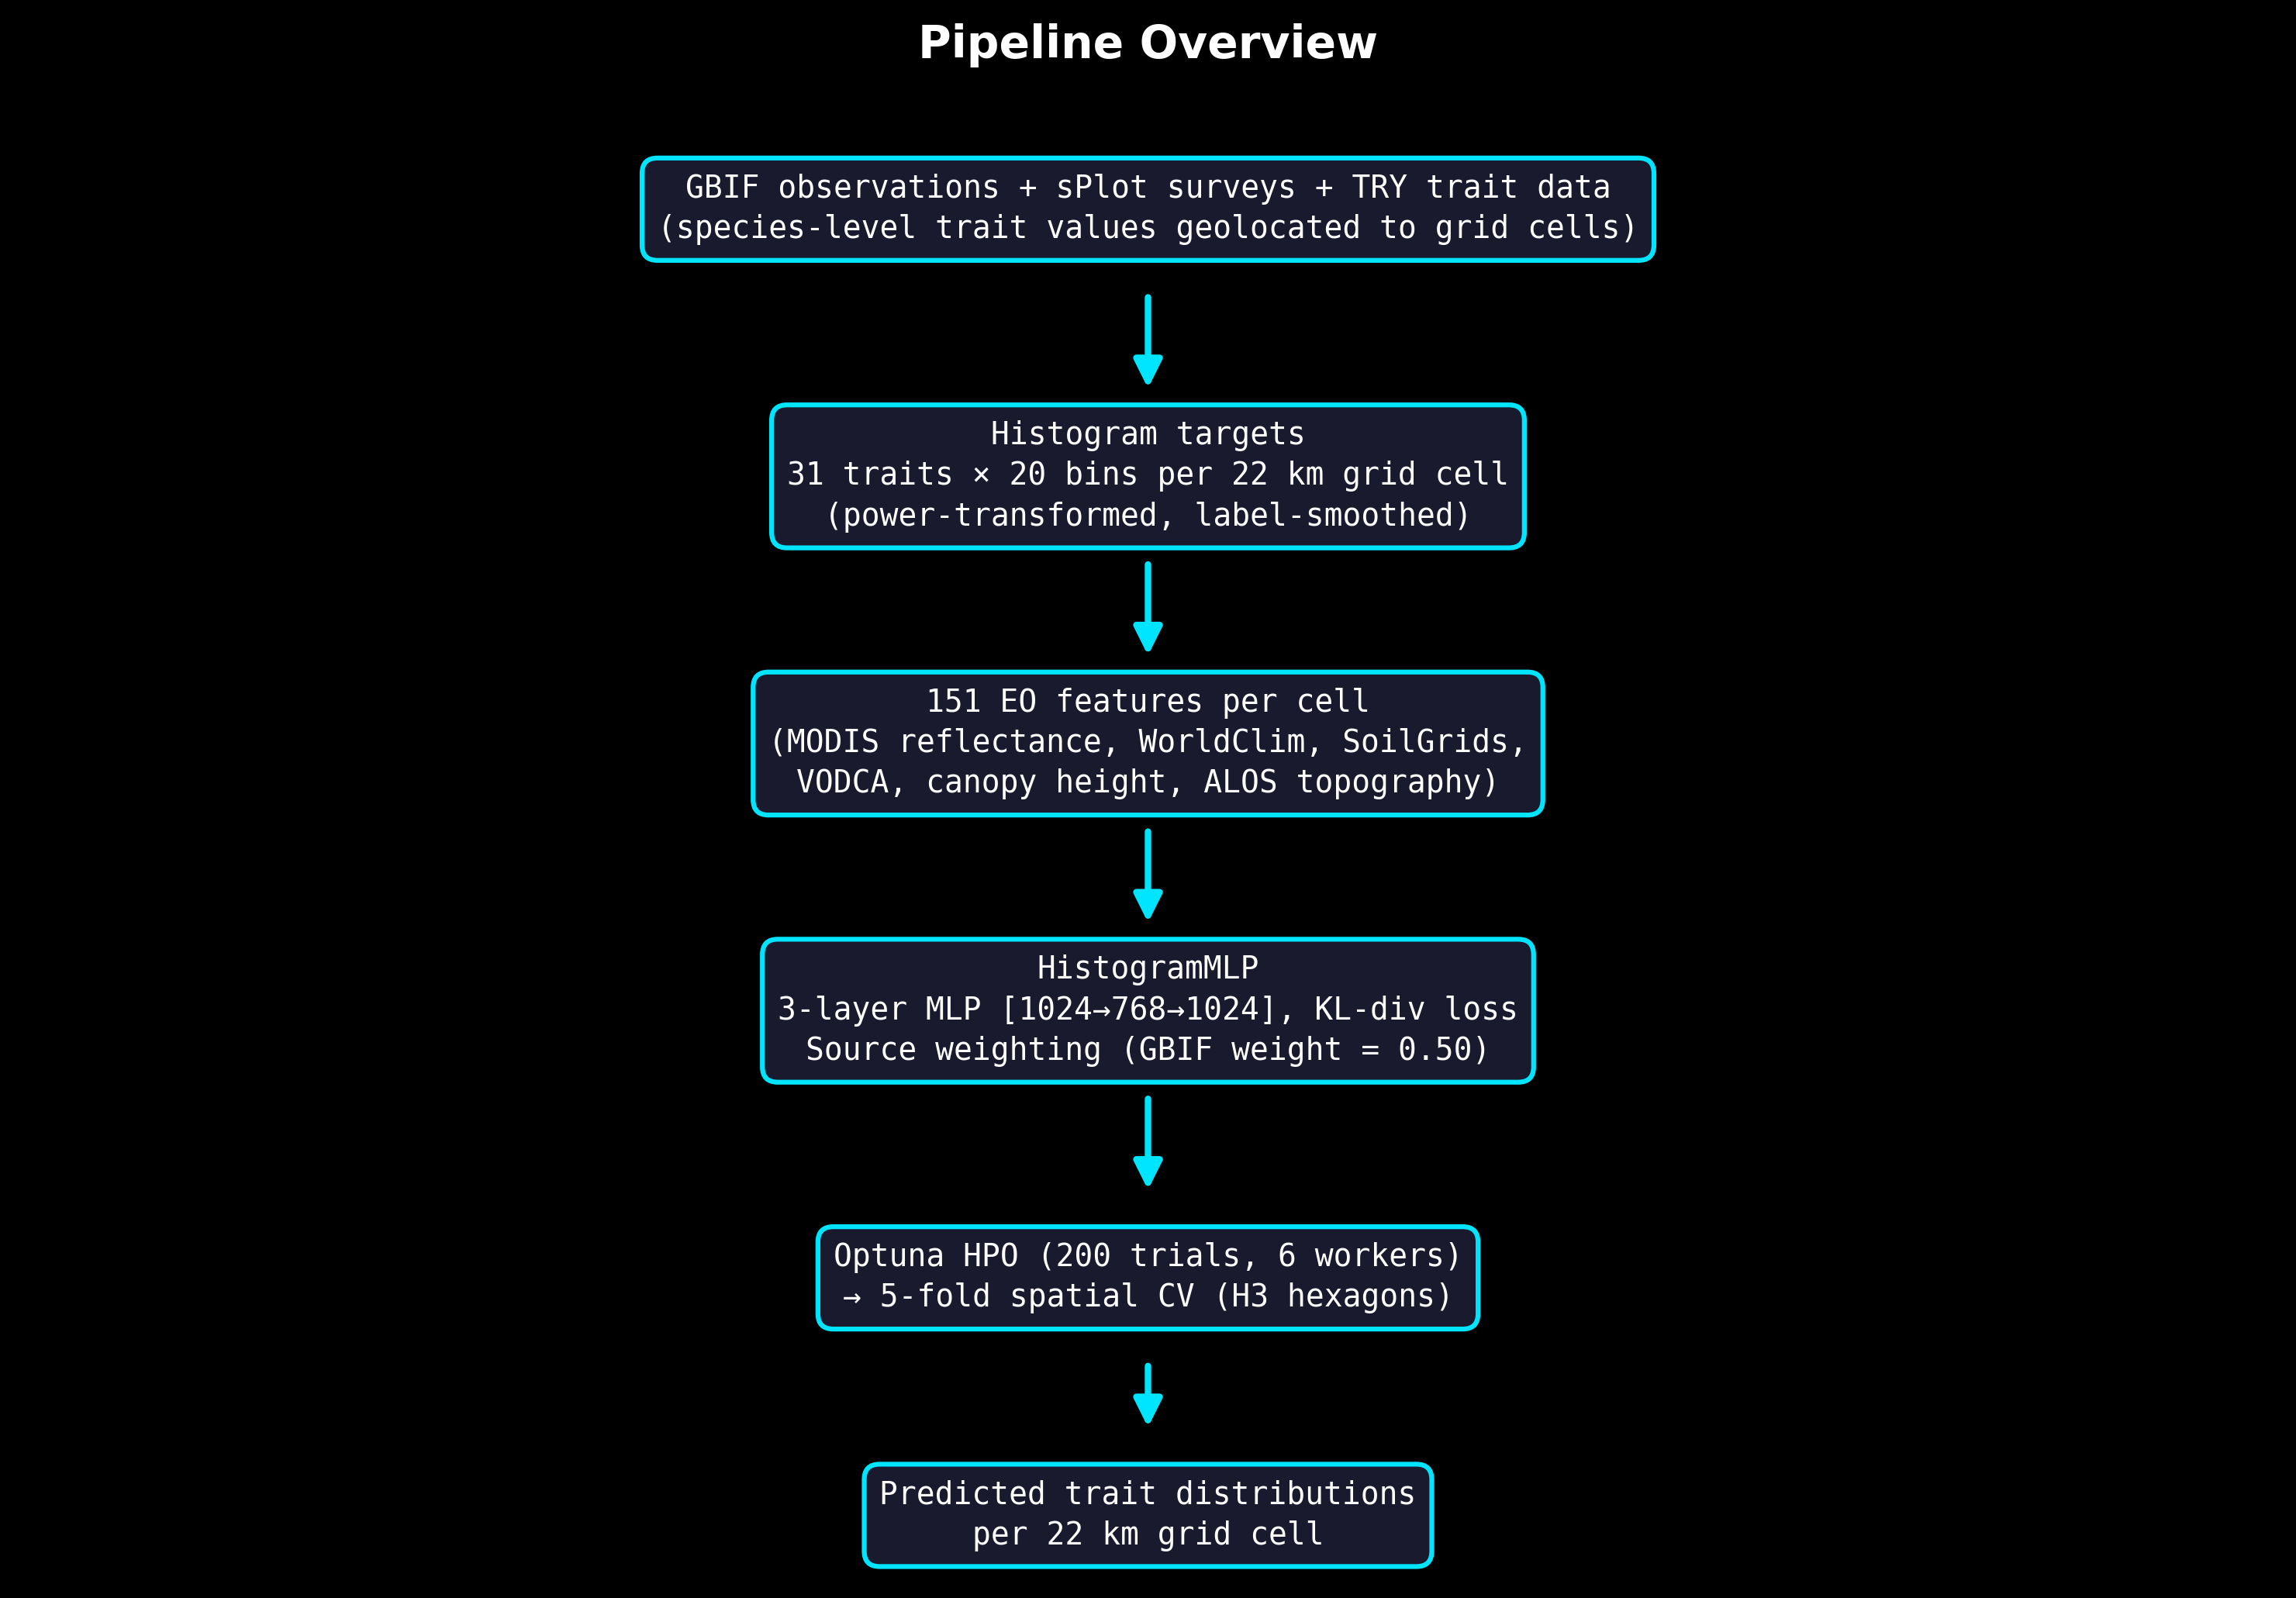

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

box_style = dict(boxstyle="round,pad=0.5", facecolor="#1a1a2e", edgecolor=C_MODEL, linewidth=1.5)
arrow_kw = dict(arrowstyle="-|>", color=C_MODEL, linewidth=2, mutation_scale=18)

boxes = [
    (5, 9.2, "GBIF observations + sPlot surveys + TRY trait data\n(species-level trait values geolocated to grid cells)"),
    (5, 7.4, "Histogram targets\n31 traits × 20 bins per 22 km grid cell\n(power-transformed, label-smoothed)"),
    (5, 5.6, "151 EO features per cell\n(MODIS reflectance, WorldClim, SoilGrids,\nVODCA, canopy height, ALOS topography)"),
    (5, 3.8, "HistogramMLP\n3-layer MLP [1024→768→1024], KL-div loss\nSource weighting (GBIF weight = 0.50)"),
    (5, 2.0, "Optuna HPO (200 trials, 6 workers)\n→ 5-fold spatial CV (H3 hexagons)"),
    (5, 0.4, "Predicted trait distributions\nper 22 km grid cell"),
]

for x, y, text in boxes:
    ax.text(x, y, text, ha="center", va="center", fontsize=9.5, bbox=box_style,
            fontfamily="monospace", linespacing=1.4, color="white")

for i in range(len(boxes) - 1):
    ax.annotate("", xy=(5, boxes[i + 1][1] + 0.55), xytext=(5, boxes[i][1] - 0.55),
                arrowprops=arrow_kw)

ax.set_title("Pipeline Overview", fontsize=14, fontweight="bold", pad=10, color="white")
fig.tight_layout()
plt.show()

## Figure 6: Predicted Histogram Mean vs. sPlot CWM

Scatter plots comparing the mean of the predicted histogram distribution against the community-weighted mean (CWM) computed directly from sPlot observations for each grid cell. Uses out-of-fold predictions across all 5 CV folds (validation = sPlot-only cells in held-out fold).

In [31]:
# Collect out-of-fold predictions across all 5 folds
# Each sPlot cell appears in exactly one validation fold

SPLOT_CWM_DIR = PROJECT_ROOT / "data/interim/splot/maps/try6_stg_pow-xf_22km"

all_val_idx = []
all_pred_probs = []

for fold_id in range(5):
    # Validation mask: sPlot cells in this fold
    fold_val_mask = (folds == fold_id) & (source == 1)
    fold_val_idx = np.where(fold_val_mask)[0]

    # Load fold model
    fold_model = HistogramMLP(
        n_features=X.shape[1], n_traits=len(trait_names), n_bins=20,
        hidden_dims=[1024, 768, 1024], dropout=0.35,
    )
    fold_model.load_state_dict(
        torch.load(CV_DIR / f"fold_{fold_id}/best_model.pt", map_location="cpu", weights_only=True)
    )
    fold_model.eval()

    with torch.no_grad():
        X_fold = torch.from_numpy(X[fold_val_idx]).float()
        log_pred = fold_model(X_fold)
        fold_preds = torch.exp(log_pred).numpy()

    all_val_idx.append(fold_val_idx)
    all_pred_probs.append(fold_preds)
    print(f"Fold {fold_id}: {len(fold_val_idx)} val cells")

all_val_idx = np.concatenate(all_val_idx)
all_pred_probs = np.concatenate(all_pred_probs, axis=0)

# Coordinates of all validation cells (from training zarr)
all_coords = np.asarray(root["coords"])
val_coords = all_coords[all_val_idx]  # (N_val, 2) — cell_x, cell_y

print(f"\nTotal out-of-fold sPlot cells: {len(all_val_idx)}")
print(f"Predictions shape: {all_pred_probs.shape}")

Fold 0: 4554 val cells
Fold 1: 3368 val cells
Fold 2: 3949 val cells
Fold 3: 3402 val cells
Fold 4: 4250 val cells

Total out-of-fold sPlot cells: 19523
Predictions shape: (19523, 31, 20)


In [32]:
# For each trait: compute predicted histogram mean, load sPlot CWM, match cells

from scipy.stats import pearsonr

trait_short = dict(zip(perf["trait_id"], perf["short_name"]))

# Build a coordinate lookup for validation cells: (cell_x, cell_y) -> position
val_coord_key = val_coords[:, 0] * 1e8 + val_coords[:, 1]  # unique key per cell

results = {}  # trait_id -> dict with matched arrays and metrics

for t_idx, tid in enumerate(trait_names):
    centers = 0.5 * (bin_edges[t_idx, :-1] + bin_edges[t_idx, 1:])

    # Predicted histogram mean per validation cell
    pred_means = (all_pred_probs[:, t_idx, :] * centers[np.newaxis, :]).sum(axis=1)

    # Load sPlot CWM for this trait
    cwm_path = SPLOT_CWM_DIR / f"{tid}.zarr"
    if not cwm_path.exists():
        continue
    cwm_store = zarr.open_group(str(cwm_path), mode="r")
    cwm_coords = np.asarray(cwm_store["coords"])
    cwm_vals = np.asarray(cwm_store["cwm"])

    # Match by coordinate key
    cwm_key = cwm_coords[:, 0] * 1e8 + cwm_coords[:, 1]
    cwm_lookup = dict(zip(cwm_key, cwm_vals))

    matched_pred = []
    matched_cwm = []
    for i, key in enumerate(val_coord_key):
        if key in cwm_lookup:
            # Also check trait is valid in histogram targets
            orig_idx = all_val_idx[i]
            if Y_mask[orig_idx, t_idx] > 0:
                matched_pred.append(pred_means[i])
                matched_cwm.append(cwm_lookup[key])

    if len(matched_pred) < 10:
        continue

    matched_pred = np.array(matched_pred)
    matched_cwm = np.array(matched_cwm)

    # Compute R² and Pearson r
    ss_res = np.sum((matched_cwm - matched_pred) ** 2)
    ss_tot = np.sum((matched_cwm - matched_cwm.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    r, _ = pearsonr(matched_pred, matched_cwm)

    results[tid] = {
        "pred": matched_pred,
        "cwm": matched_cwm,
        "r2": r2,
        "r": r,
        "n": len(matched_pred),
        "name": trait_short.get(tid, tid),
    }

print(f"Matched {len(results)} traits")
for tid, res in sorted(results.items(), key=lambda x: -x[1]["r2"]):
    print(f"  {res['name']:30s}  R²={res['r2']:.3f}  r={res['r']:.3f}  n={res['n']}")

Matched 31 traits
  Leaf N (area)                   R²=0.569  r=0.760  n=19106
  Leaf P                          R²=0.552  r=0.752  n=19113
  Leaf area (3114)                R²=0.547  r=0.745  n=18970
  Stem conduit diameter           R²=0.526  r=0.730  n=19081
  Stem conduit density            R²=0.526  r=0.745  n=19044
  SLA                             R²=0.509  r=0.733  n=19050
  Leaf dry mass                   R²=0.488  r=0.704  n=19102
  Rooting depth                   R²=0.465  r=0.685  n=19211
  Leaf fresh mass                 R²=0.459  r=0.708  n=18580
  Leaf delta 15N                  R²=0.458  r=0.685  n=19019
  Leaf length                     R²=0.452  r=0.682  n=19048
  Leaf width                      R²=0.446  r=0.688  n=18980
  Leaf thickness                  R²=0.426  r=0.658  n=19098
  SSD                             R²=0.394  r=0.636  n=19024
  Seed mass                       R²=0.377  r=0.616  n=19217
  Leaf C/N ratio                  R²=0.353  r=0.605  n=19048
  Leaf

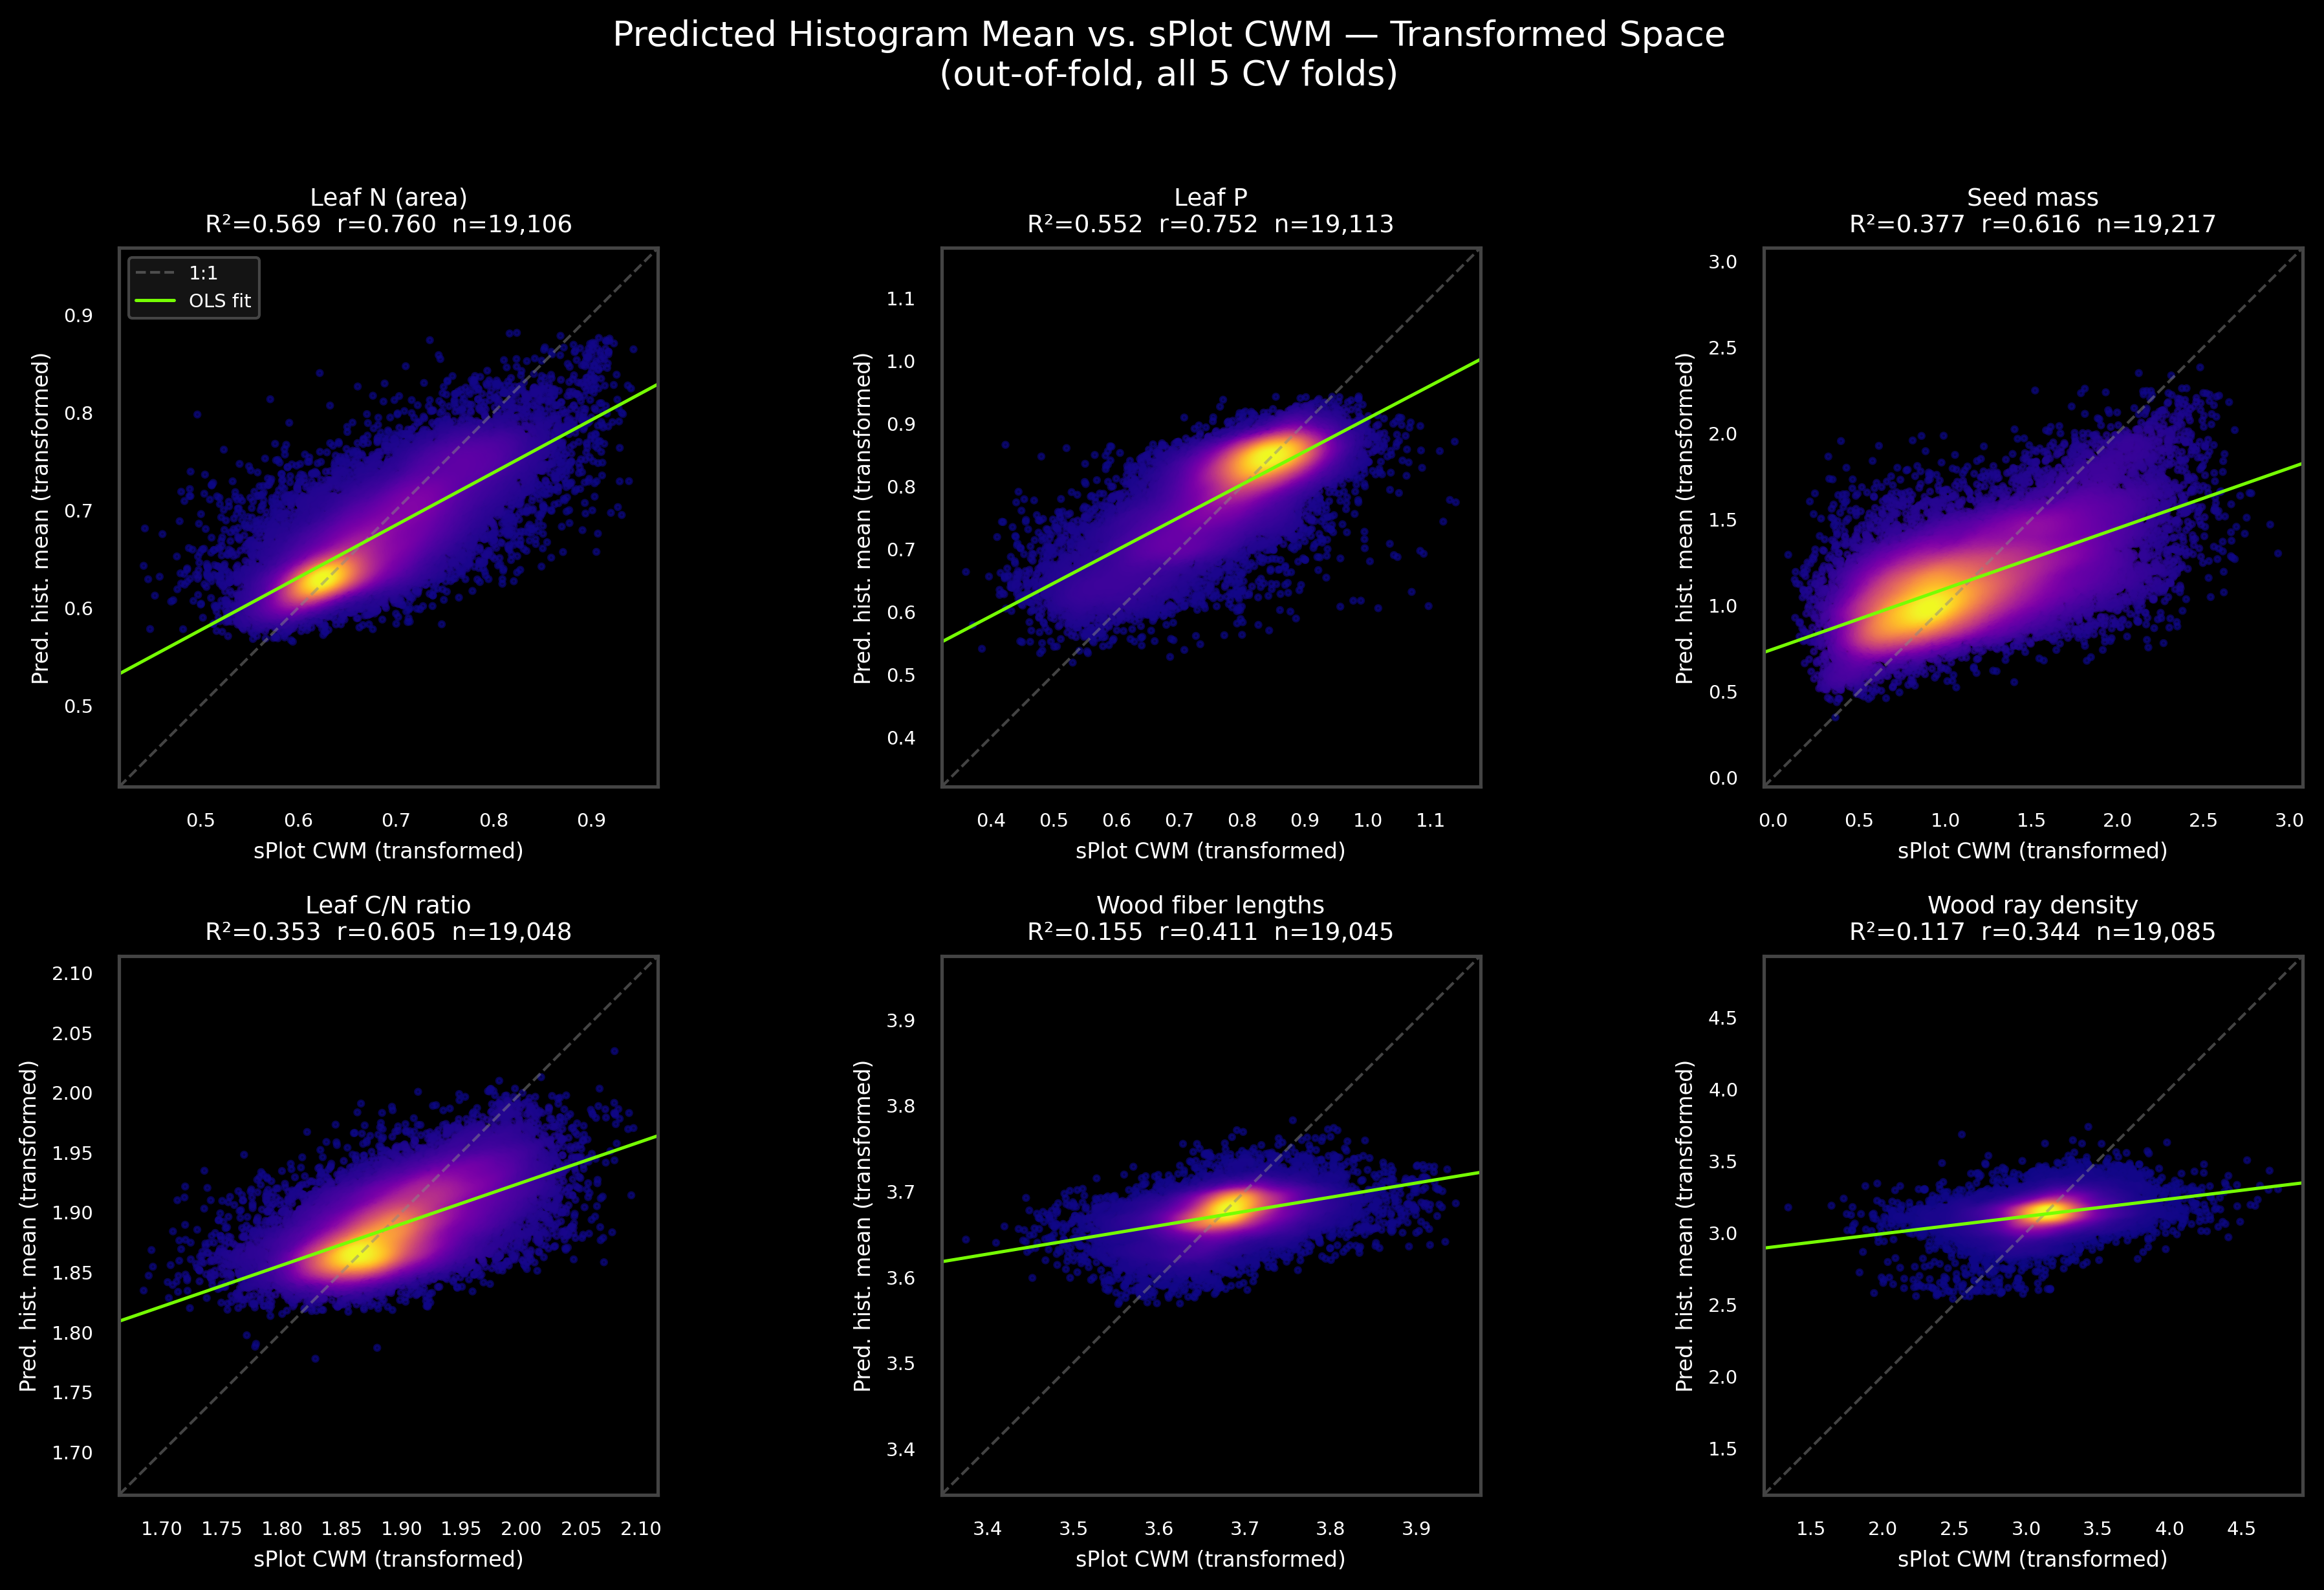

In [33]:
# Plot KDE: predicted histogram mean vs sPlot CWM (transformed space)
# Show 6 traits spanning the R² range

from scipy.stats import linregress, gaussian_kde

sorted_traits = sorted(results.keys(), key=lambda t: -results[t]["r2"])

# Pick top 2, middle 2, bottom 2
n = len(sorted_traits)
pick_idx = [0, 1, n // 2 - 1, n // 2, n - 2, n - 1]
pick_idx = sorted(set(min(i, n - 1) for i in pick_idx))
show_tids = [sorted_traits[i] for i in pick_idx[:6]]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, tid in zip(axes.flat, show_tids):
    res = results[tid]
    x_vals, y_vals = res["cwm"], res["pred"]

    # KDE density coloring
    try:
        xy = np.vstack([x_vals, y_vals])
        kde = gaussian_kde(xy)
        density = kde(xy)
        order = density.argsort()
        ax.scatter(x_vals[order], y_vals[order], c=density[order], s=4, alpha=0.6,
                   cmap="plasma", rasterized=True)
    except np.linalg.LinAlgError:
        ax.scatter(x_vals, y_vals, s=4, alpha=0.3, color=C_MODEL, rasterized=True)

    # 1:1 line
    lo = min(x_vals.min(), y_vals.min())
    hi = max(x_vals.max(), y_vals.max())
    margin = (hi - lo) * 0.05
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
            color=C_LINE, linewidth=1, linestyle="--", alpha=0.5, label="1:1")

    # Regression line
    slope, intercept, r_val, _, _ = linregress(x_vals, y_vals)
    reg_x = np.array([lo - margin, hi + margin])
    ax.plot(reg_x, slope * reg_x + intercept, color=C_ACCENT, linewidth=1.2, label="OLS fit")

    ax.set_xlim(lo - margin, hi + margin)
    ax.set_ylim(lo - margin, hi + margin)
    ax.set_aspect("equal")
    ax.set_title(f"{res['name']}\nR²={res['r2']:.3f}  r={res['r']:.3f}  n={res['n']:,}", fontsize=9)
    ax.set_xlabel("sPlot CWM (transformed)", fontsize=8)
    ax.set_ylabel("Pred. hist. mean (transformed)", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=7, loc="upper left")
fig.suptitle(
    "Predicted Histogram Mean vs. sPlot CWM — Transformed Space\n(out-of-fold, all 5 CV folds)",
    fontsize=13, y=1.02, color="white",
)
fig.tight_layout()
plt.show()

In [34]:
# Back-transform to original trait space and replot
import pickle

TRANSFORMER_DIR = PROJECT_ROOT / "data/interim/traits/try6_pow-xf/transformers"

# Load all transformers
transformers = {}
for tid in trait_names:
    meta_path = TRANSFORMER_DIR / f"{tid}_metadata.json"
    pkl_path = TRANSFORMER_DIR / f"{tid}_transformer.pkl"
    if meta_path.exists():
        with open(meta_path) as f:
            meta = json.load(f)
        if meta.get("transformed", False) and pkl_path.exists():
            with open(pkl_path, "rb") as f:
                transformers[tid] = pickle.load(f)

def back_transform(values, tid):
    """Back-transform values to original scale. Returns as-is if no transformer."""
    pt = transformers.get(tid)
    if pt is None:
        return values
    return pt.inverse_transform(values.reshape(-1, 1)).ravel()

# Build back-transformed results
results_orig = {}
for tid, res in results.items():
    pred_orig = back_transform(res["pred"], tid)
    cwm_orig = back_transform(res["cwm"], tid)

    ss_res = np.sum((cwm_orig - pred_orig) ** 2)
    ss_tot = np.sum((cwm_orig - cwm_orig.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    r, _ = pearsonr(pred_orig, cwm_orig)

    results_orig[tid] = {
        "pred": pred_orig, "cwm": cwm_orig,
        "r2": r2, "r": r, "n": res["n"], "name": res["name"],
    }

print("Back-transformed R² per trait:")
for tid, res in sorted(results_orig.items(), key=lambda x: -x[1]["r2"]):
    print(f"  {res['name']:30s}  R²={res['r2']:.3f}  r={res['r']:.3f}")

Back-transformed R² per trait:
  Leaf N (area)                   R²=0.562  r=0.765
  Stem conduit diameter           R²=0.548  r=0.744
  Leaf dry mass                   R²=0.547  r=0.755
  Leaf P                          R²=0.531  r=0.732
  Leaf area (3114)                R²=0.527  r=0.750
  Leaf fresh mass                 R²=0.514  r=0.728
  SLA                             R²=0.489  r=0.707
  Leaf delta 15N                  R²=0.459  r=0.685
  Leaf width                      R²=0.435  r=0.666
  Rooting depth                   R²=0.422  r=0.679
  Leaf length                     R²=0.407  r=0.647
  SSD                             R²=0.394  r=0.637
  Leaf thickness                  R²=0.371  r=0.621
  Leaf N (mass)                   R²=0.350  r=0.602
  Leaf C/N ratio                  R²=0.337  r=0.611
  Leaf water content              R²=0.288  r=0.561
  Stem diameter                   R²=0.284  r=0.561
  Seed length                     R²=0.278  r=0.579
  LDMC                           

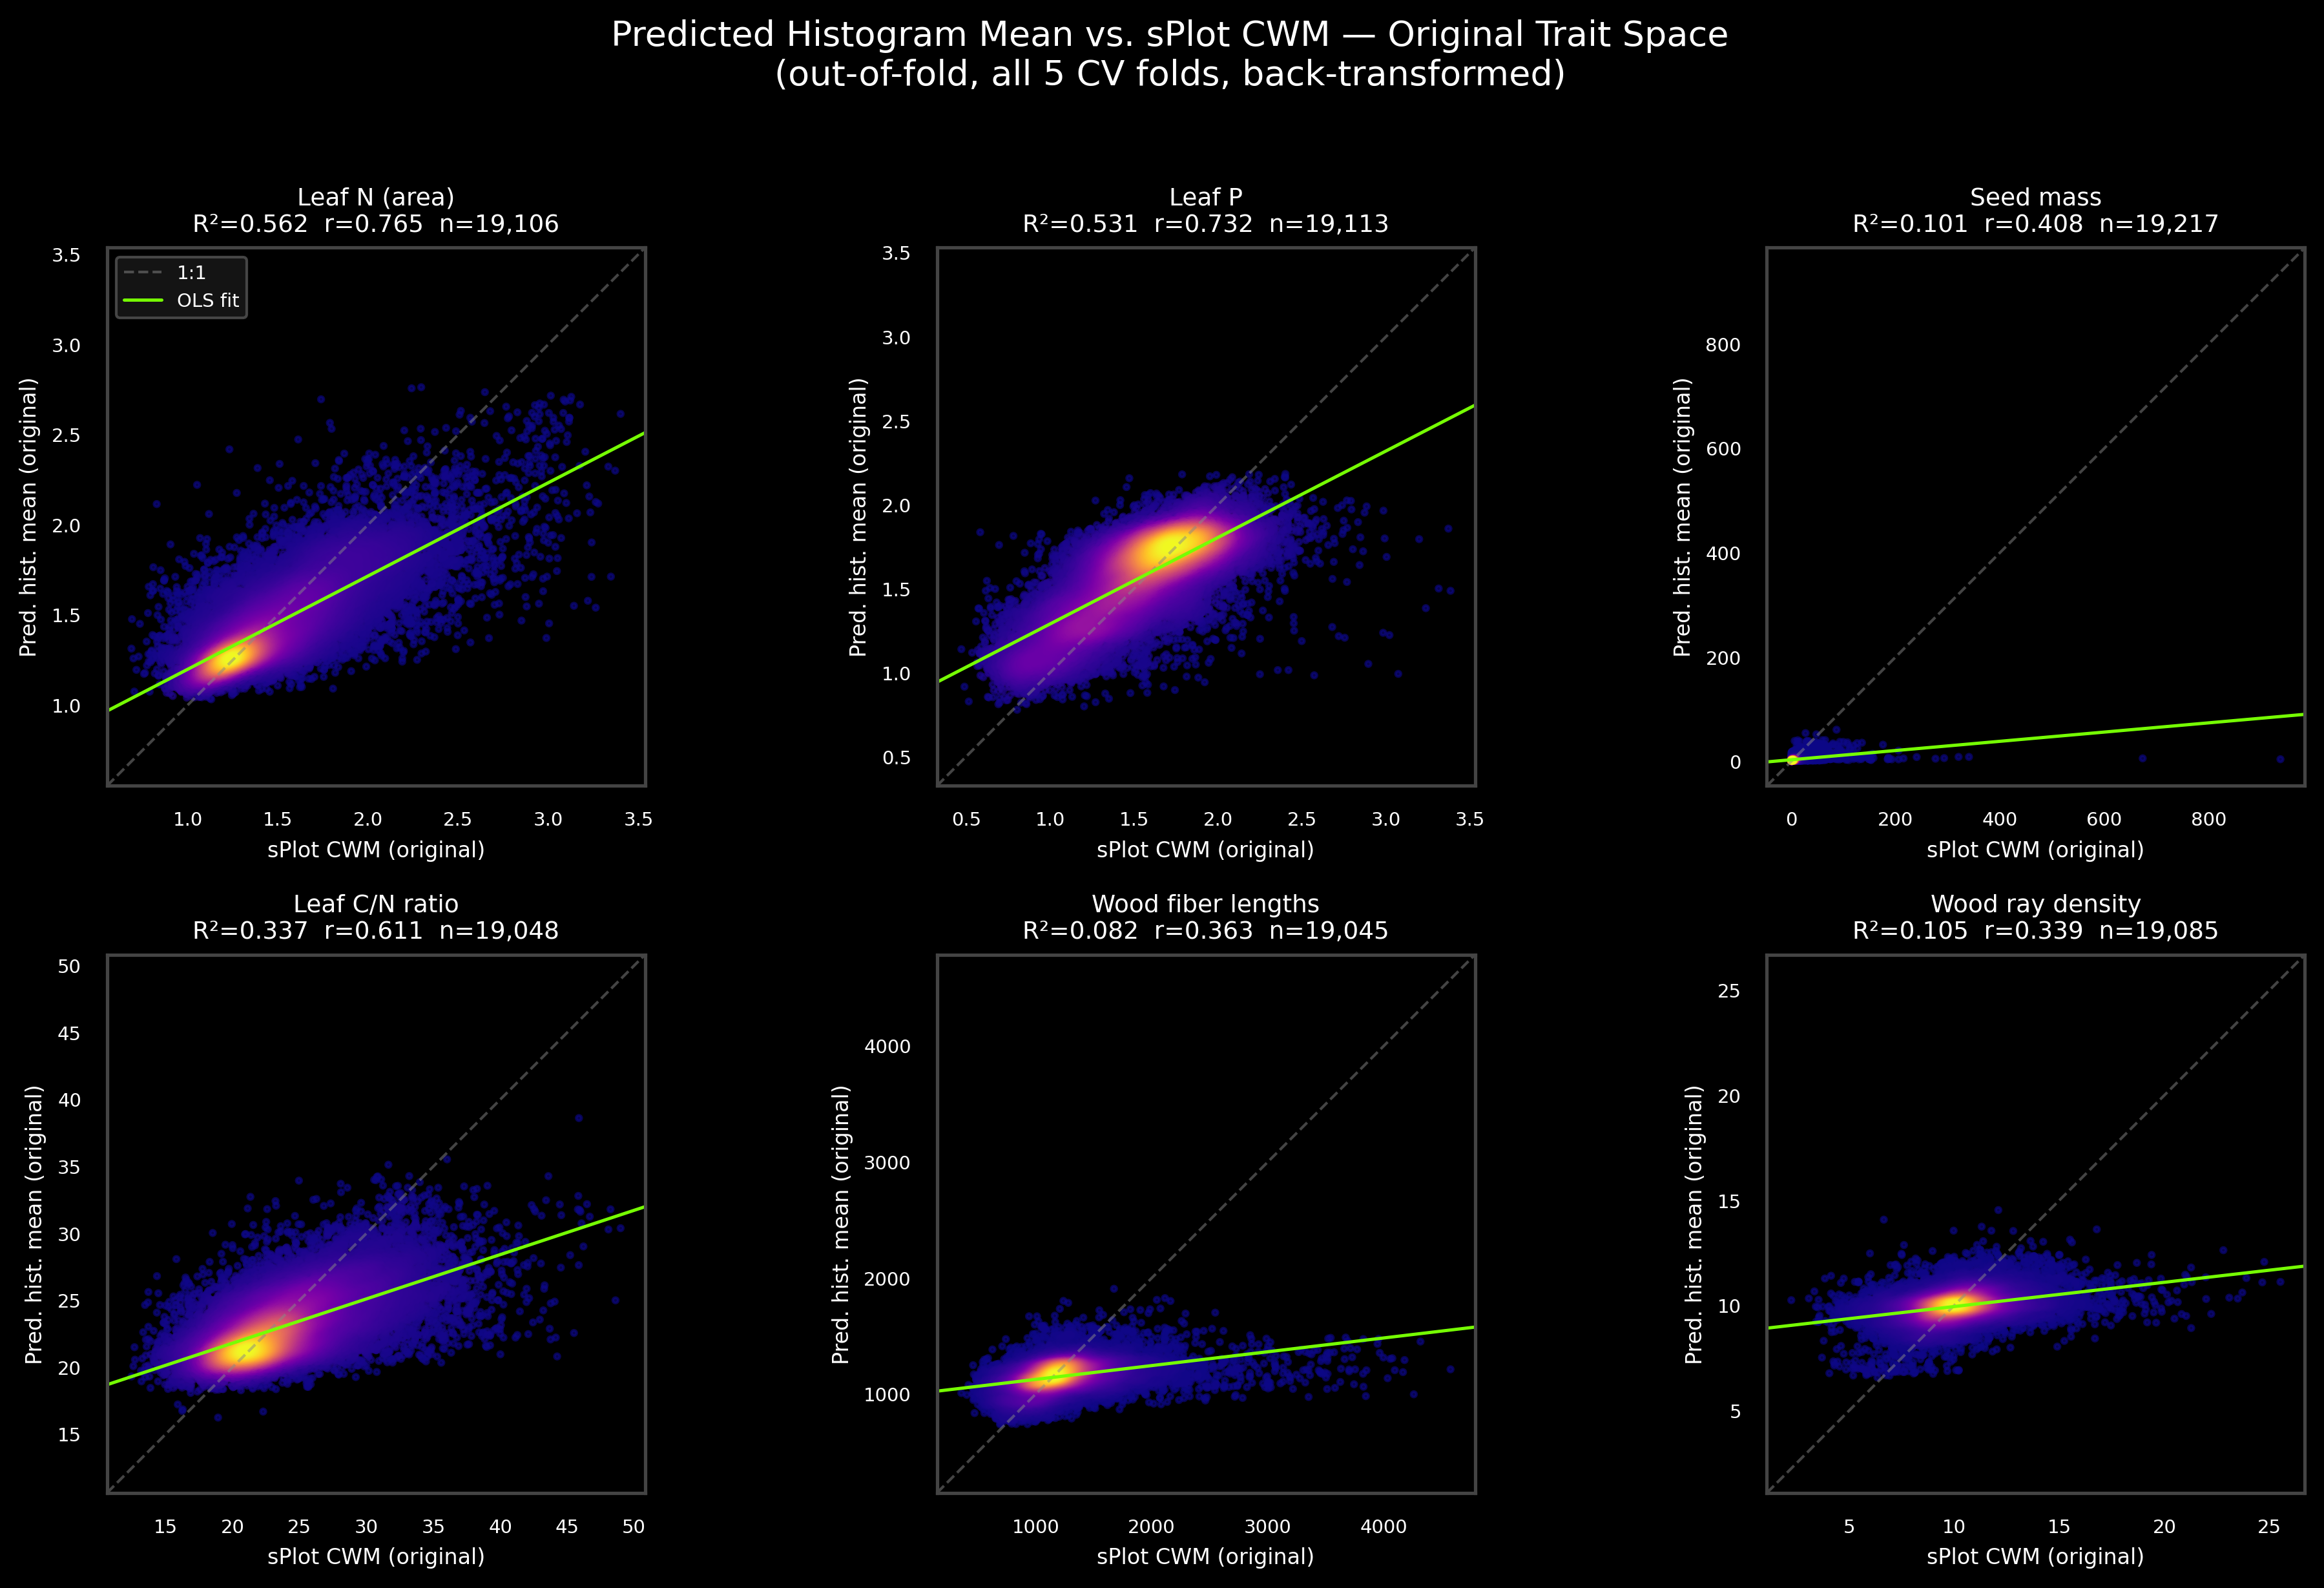

In [35]:
# Same 6 traits, back-transformed to original scale

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, tid in zip(axes.flat, show_tids):
    res = results_orig[tid]
    x_vals, y_vals = res["cwm"], res["pred"]

    # KDE density coloring
    try:
        xy = np.vstack([x_vals, y_vals])
        kde = gaussian_kde(xy)
        density = kde(xy)
        order = density.argsort()
        ax.scatter(x_vals[order], y_vals[order], c=density[order], s=4, alpha=0.6,
                   cmap="plasma", rasterized=True)
    except np.linalg.LinAlgError:
        ax.scatter(x_vals, y_vals, s=4, alpha=0.3, color=C_MODEL, rasterized=True)

    # 1:1 line
    lo = min(x_vals.min(), y_vals.min())
    hi = max(x_vals.max(), y_vals.max())
    margin = (hi - lo) * 0.05
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
            color=C_LINE, linewidth=1, linestyle="--", alpha=0.5, label="1:1")

    # Regression line
    slope, intercept, r_val, _, _ = linregress(x_vals, y_vals)
    reg_x = np.array([lo - margin, hi + margin])
    ax.plot(reg_x, slope * reg_x + intercept, color=C_ACCENT, linewidth=1.2, label="OLS fit")

    ax.set_xlim(lo - margin, hi + margin)
    ax.set_ylim(lo - margin, hi + margin)
    ax.set_aspect("equal")
    ax.set_title(f"{res['name']}\nR²={res['r2']:.3f}  r={res['r']:.3f}  n={res['n']:,}", fontsize=9)
    ax.set_xlabel("sPlot CWM (original)", fontsize=8)
    ax.set_ylabel("Pred. hist. mean (original)", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=7, loc="upper left")
fig.suptitle(
    "Predicted Histogram Mean vs. sPlot CWM — Original Trait Space\n(out-of-fold, all 5 CV folds, back-transformed)",
    fontsize=13, y=1.02, color="white",
)
fig.tight_layout()
plt.show()

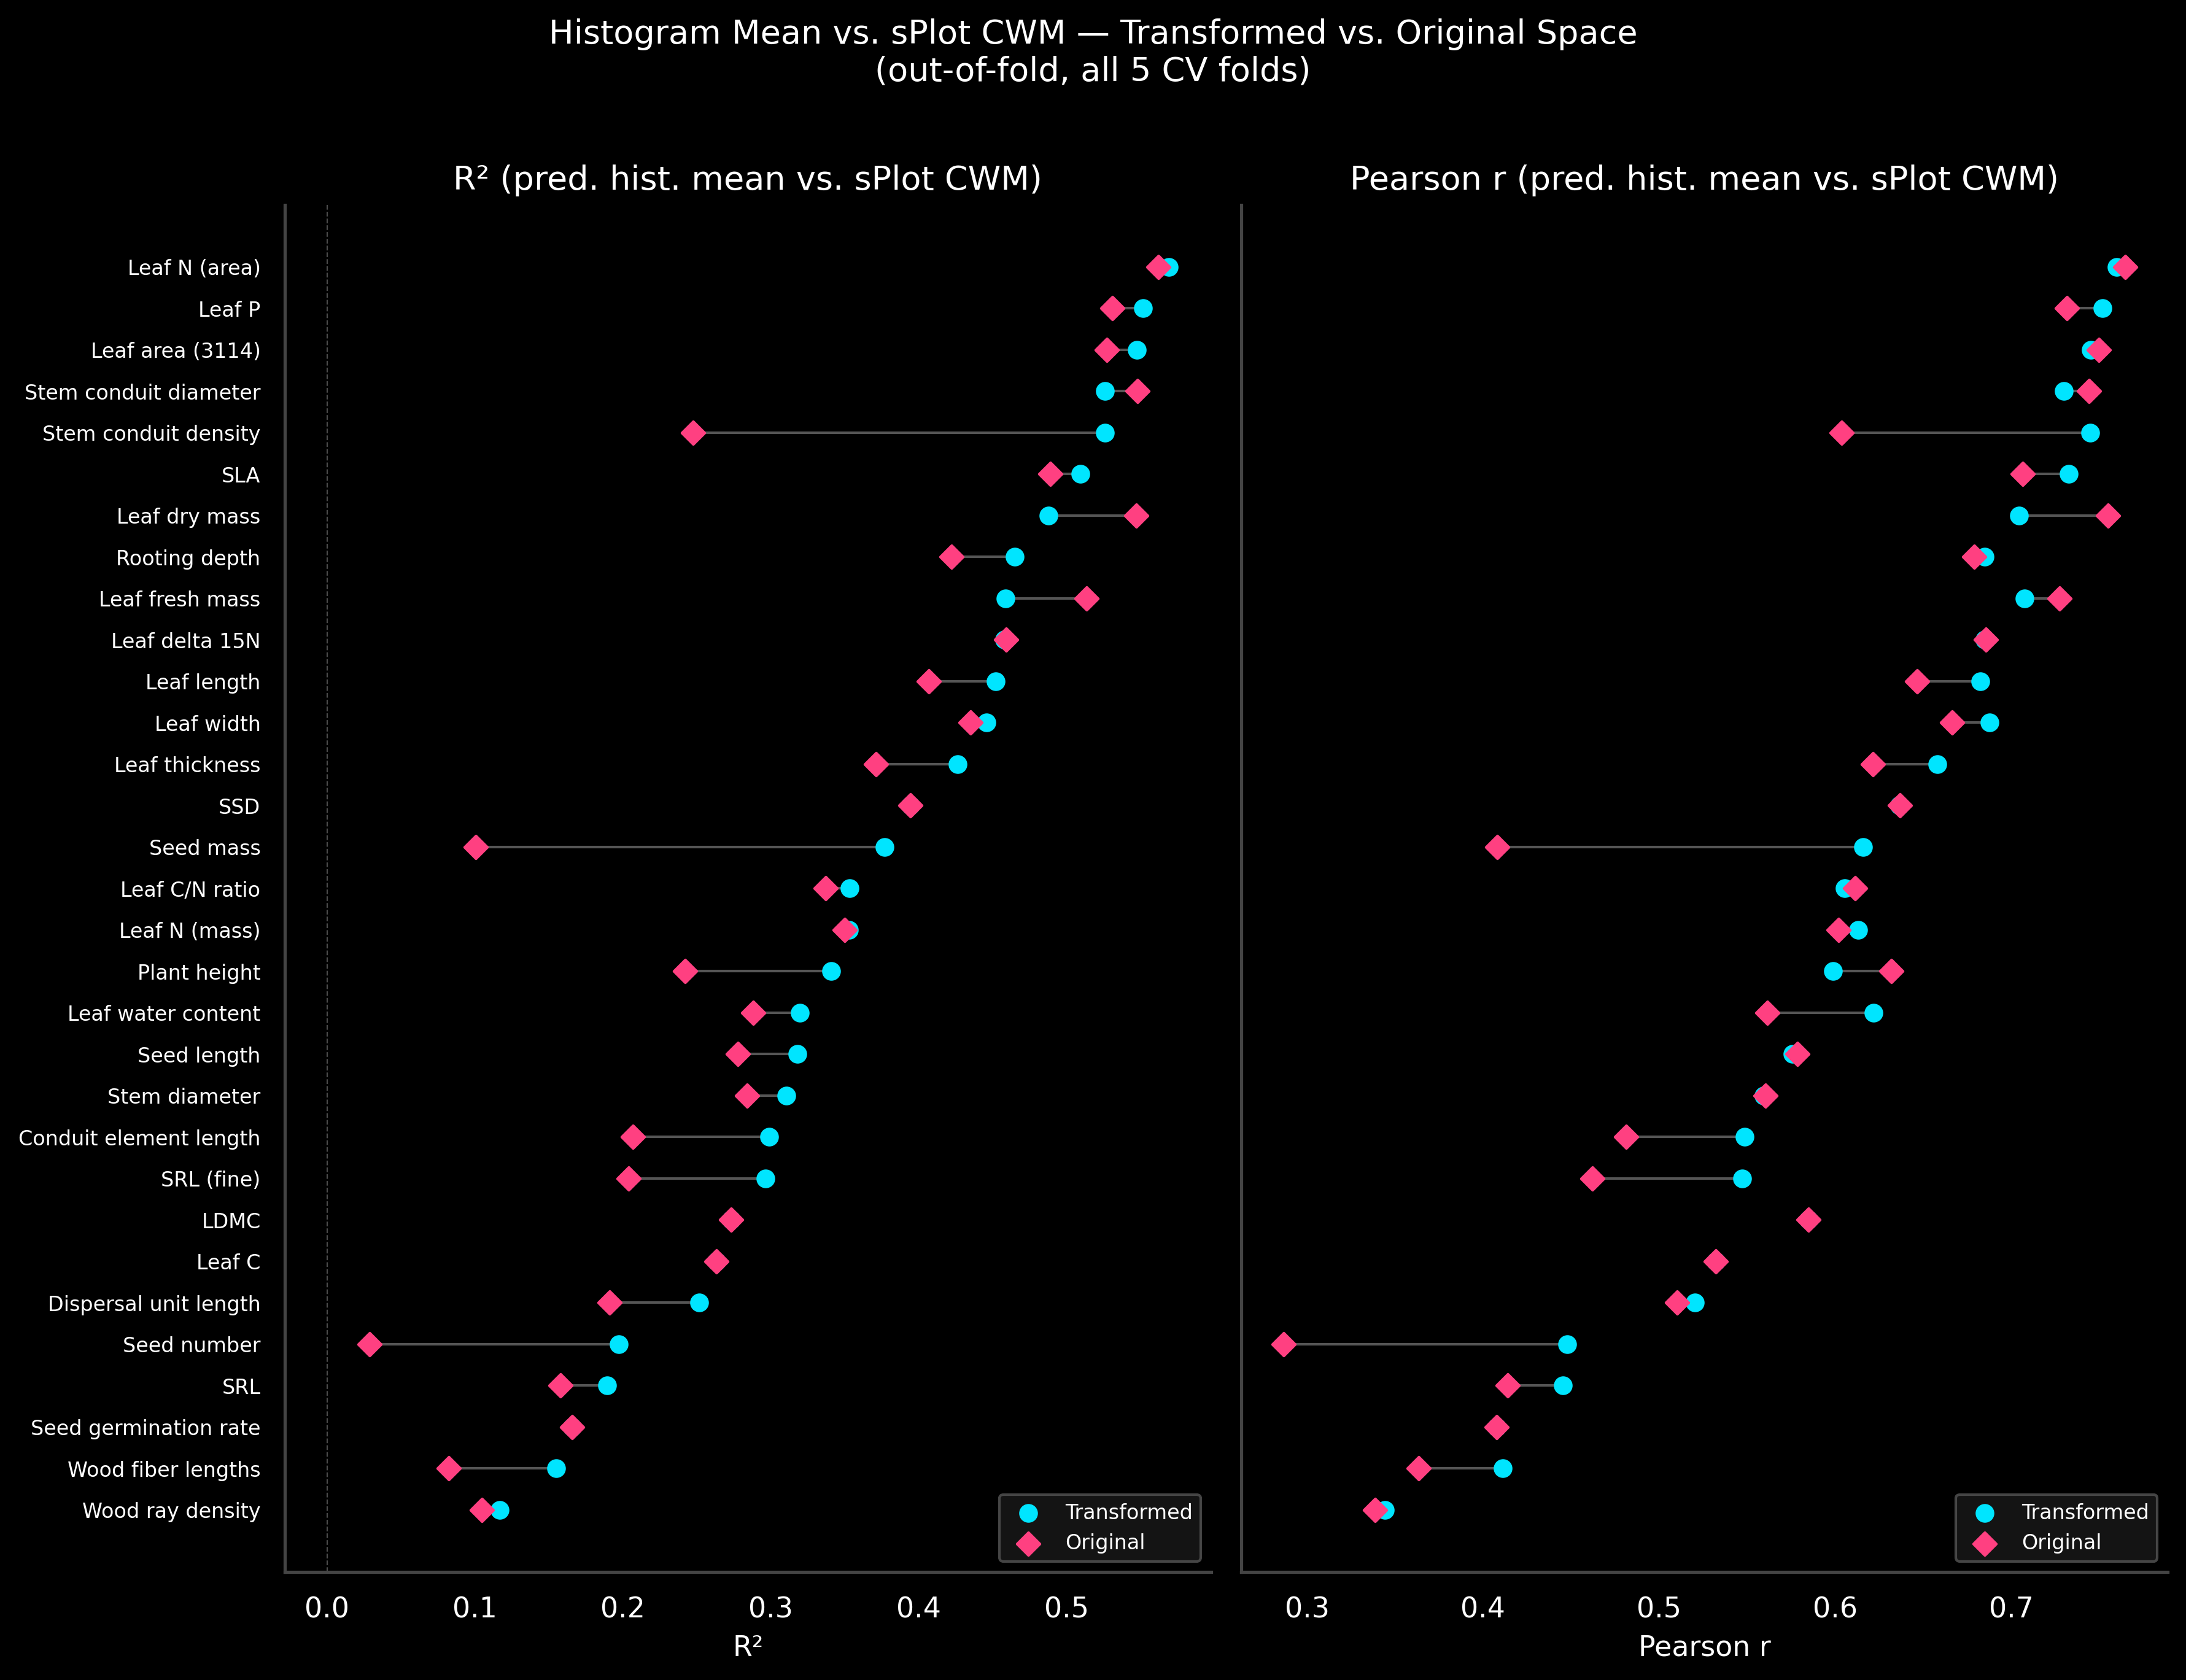

In [36]:
# Paired comparison: R² and r in transformed vs original space (all traits)

compare_rows = []
for tid in results:
    compare_rows.append({
        "trait": results[tid]["name"],
        "R²_trans": results[tid]["r2"],
        "R²_orig": results_orig[tid]["r2"],
        "r_trans": results[tid]["r"],
        "r_orig": results_orig[tid]["r"],
        "n": results[tid]["n"],
    })

cdf = pd.DataFrame(compare_rows).sort_values("R²_trans", ascending=True).reset_index(drop=True)
y = np.arange(len(cdf))

fig, (ax_r2, ax_r) = plt.subplots(1, 2, figsize=(12, 9), sharey=True)

# --- R² panel ---
for i, row in cdf.iterrows():
    ax_r2.plot([row["R²_orig"], row["R²_trans"]], [i, i], color="#555555", linewidth=1, zorder=1)
ax_r2.scatter(cdf["R²_trans"], y, color=C_MODEL, s=40, zorder=2, label="Transformed")
ax_r2.scatter(cdf["R²_orig"], y, color=C_BASE, s=40, zorder=2, marker="D", label="Original")
ax_r2.set_yticks(y)
ax_r2.set_yticklabels(cdf["trait"], fontsize=8)
ax_r2.set_xlabel("R²")
ax_r2.set_title("R² (pred. hist. mean vs. sPlot CWM)")
ax_r2.axvline(0, color="white", linewidth=0.5, linestyle="--", alpha=0.3)
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.spines[["top", "right"]].set_visible(False)

# --- Pearson r panel ---
for i, row in cdf.iterrows():
    ax_r.plot([row["r_orig"], row["r_trans"]], [i, i], color="#555555", linewidth=1, zorder=1)
ax_r.scatter(cdf["r_trans"], y, color=C_MODEL, s=40, zorder=2, label="Transformed")
ax_r.scatter(cdf["r_orig"], y, color=C_BASE, s=40, zorder=2, marker="D", label="Original")
ax_r.set_xlabel("Pearson r")
ax_r.set_title("Pearson r (pred. hist. mean vs. sPlot CWM)")
ax_r.legend(fontsize=8, loc="lower right")
ax_r.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Histogram Mean vs. sPlot CWM — Transformed vs. Original Space\n(out-of-fold, all 5 CV folds)",
    fontsize=13, y=1.01, color="white",
)
fig.tight_layout()
plt.show()

## Figure 8: Histogram Model vs. Old CWM Model (GBM)

Lollipop chart comparing the R² of the new histogram model's predicted means against the old single-trait GBM models (both validated against held-out sPlot CWMs, both in power-transformed space at 22km).

In [ ]:
# Load old CWM model results (22km, power-transformed, splot_gbif training set)
old_results = pd.read_parquet(PROJECT_ROOT / "results/all_results.parquet")
old_sub = old_results[
    (old_results["resolution"] == "22km")
    & (old_results["transform"] == "power")
    & (old_results["trait_set"] == "splot_gbif")
].copy()
# Normalize trait_id: "X4_mean" -> "X4"
old_sub["trait_id_clean"] = old_sub["trait_id"].str.replace("_mean", "", regex=False)

# Build comparison dataframe — only traits present in both
hist_r2 = {tid: results[tid]["r2"] for tid in results}
hist_r = {tid: results[tid]["r"] for tid in results}
hist_names = {tid: results[tid]["name"] for tid in results}

rows = []
for _, row in old_sub.iterrows():
    tid = row["trait_id_clean"]
    if tid in hist_r2:
        rows.append({
            "trait_id": tid,
            "trait": hist_names[tid],
            "old_r2": row["r2"],
            "old_r": row["pearsonr"],
            "hist_r2": hist_r2[tid],
            "hist_r": hist_r[tid],
        })

mdf = pd.DataFrame(rows).sort_values("hist_r2", ascending=True).reset_index(drop=True)
mdf["delta_r2"] = mdf["hist_r2"] - mdf["old_r2"]
mdf["delta_r"] = mdf["hist_r"] - mdf["old_r"]

print(f"Matched {len(mdf)} traits between histogram model and old GBM")
print(f"\nR²:        Histogram mean = {mdf['hist_r2'].mean():.3f}, GBM mean = {mdf['old_r2'].mean():.3f}  |  Hist wins: {(mdf['delta_r2'] > 0).sum()}/{len(mdf)}")
print(f"Pearson r: Histogram mean = {mdf['hist_r'].mean():.3f}, GBM mean = {mdf['old_r'].mean():.3f}  |  Hist wins: {(mdf['delta_r'] > 0).sum()}/{len(mdf)}")

In [ ]:
y = np.arange(len(mdf))

fig, (ax_r2, ax_r) = plt.subplots(1, 2, figsize=(14, 9), sharey=True)

GUIDE_COLOR = "#555555"

# --- R² panel ---
for i, row in mdf.iterrows():
    ax_r2.axhline(i, color=GUIDE_COLOR, linewidth=0.5, zorder=0, xmin=-0.05)
    ax_r2.plot([row["old_r2"], row["hist_r2"]], [i, i], color="#666666", linewidth=1.2, zorder=1)
ax_r2.scatter(mdf["old_r2"], y, color=C_BASE, s=50, zorder=2, label="Old GBM (per-trait CWM)")
ax_r2.scatter(mdf["hist_r2"], y, color=C_MODEL, s=50, zorder=2, label="Histogram MLP (mean)")
for i, row in mdf.iterrows():
    x_pos = max(row["hist_r2"], row["old_r2"]) + 0.01
    delta = row["delta_r2"]
    sign = "+" if delta > 0 else ""
    color = C_ACCENT if delta > 0 else C_BASE
    ax_r2.text(x_pos, i, f"{sign}{delta:.2f}", va="center", fontsize=7.5, color=color)
ax_r2.axvline(0, color="white", linewidth=0.5, linestyle="--", alpha=0.3)
ax_r2.set_yticks(y)
ax_r2.set_yticklabels(mdf["trait"], fontsize=8.5)
ax_r2.set_xlabel("R²")
ax_r2.set_title(f"R² (hist = {mdf['hist_r2'].mean():.3f}, GBM = {mdf['old_r2'].mean():.3f})")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.spines[["top", "right"]].set_visible(False)
ax_r2.set_clip_on(False)

# --- Pearson r panel (re-sort by hist_r for this panel's ordering) ---
mdf_r = mdf.sort_values("hist_r", ascending=True).reset_index(drop=True)
y_r = np.arange(len(mdf_r))
for i, row in mdf_r.iterrows():
    ax_r.axhline(i, color=GUIDE_COLOR, linewidth=0.5, zorder=0)
    ax_r.plot([row["old_r"], row["hist_r"]], [i, i], color="#666666", linewidth=1.2, zorder=1)
ax_r.scatter(mdf_r["old_r"], y_r, color=C_BASE, s=50, zorder=2, label="Old GBM (per-trait CWM)")
ax_r.scatter(mdf_r["hist_r"], y_r, color=C_MODEL, s=50, zorder=2, label="Histogram MLP (mean)")
for i, row in mdf_r.iterrows():
    x_pos = max(row["hist_r"], row["old_r"]) + 0.005
    delta = row["delta_r"]
    sign = "+" if delta > 0 else ""
    color = C_ACCENT if delta > 0 else C_BASE
    ax_r.text(x_pos, i, f"{sign}{delta:.3f}", va="center", fontsize=7.5, color=color)
ax_r.set_yticks(y_r)
ax_r.set_yticklabels(mdf_r["trait"], fontsize=8.5)
ax_r.set_xlabel("Pearson r")
ax_r.set_title(f"Pearson r (hist = {mdf_r['hist_r'].mean():.3f}, GBM = {mdf_r['old_r'].mean():.3f})")
ax_r.legend(fontsize=8, loc="lower right")
ax_r.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Histogram MLP vs. Old GBM — Pred. Mean vs. sPlot CWM (power-transformed)",
    fontsize=13, y=1.01, color="white",
)
fig.tight_layout()
plt.show()

### Traits where GBM outperforms the histogram mean

Explore the transformed and back-transformed trait distributions for traits where the old GBM model achieves higher R² than the histogram model's predicted mean.

In [ ]:
import pickle

# Traits where GBM wins
gbm_wins = mdf[mdf["delta_r2"] < 0].sort_values("delta_r2", ascending=True)
losing_traits = list(gbm_wins["trait_id"].values)
print(f"GBM outperforms histogram mean on {len(losing_traits)} traits:")
for _, row in gbm_wins.iterrows():
    print(f"  {row['trait']:25s} ({row['trait_id']:>5s})  hist R²={row['hist_r2']:.3f}  GBM R²={row['old_r2']:.3f}  Δ={row['delta_r2']:+.3f}")

# Load trait data (transformed space)
trait_df = pd.read_parquet(PROJECT_ROOT / "data/interim/traits/try6_pow-xf/try6_pow-xf.parquet")

# Load back-transformers
TRANSFORMER_DIR = PROJECT_ROOT / "data/interim/traits/try6_pow-xf/transformers"

n_traits = len(losing_traits)
ncols = min(n_traits, 4)
nrows = (n_traits + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
if nrows * ncols == 1:
    axes = np.array([axes])
axes = axes.flat

for idx, tid in enumerate(losing_traits):
    ax = axes[idx]
    name = gbm_wins.loc[gbm_wins["trait_id"] == tid, "trait"].values[0]

    vals = trait_df[tid].dropna().values
    ax.hist(vals, bins=60, color=C_MODEL, alpha=0.8, edgecolor="black", linewidth=0.3)
    ax.set_title(f"{name} ({tid})\ntransformed", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_ylabel("Count", fontsize=8)

# Hide unused axes
for idx in range(len(losing_traits), nrows * ncols):
    axes[idx].set_visible(False)

fig.suptitle("Transformed trait distributions — traits where GBM > histogram mean", fontsize=12, y=1.01, color="white")
fig.tight_layout()
plt.show()

# Back-transformed distributions
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
if nrows * ncols == 1:
    axes2 = np.array([axes2])
axes2 = axes2.flat

for idx, tid in enumerate(losing_traits):
    ax = axes2[idx]
    name = gbm_wins.loc[gbm_wins["trait_id"] == tid, "trait"].values[0]

    vals_trans = trait_df[tid].dropna().values

    # Back-transform
    tf_path = TRANSFORMER_DIR / f"{tid}_transformer.pkl"
    if tf_path.exists():
        with open(tf_path, "rb") as f:
            transformer = pickle.load(f)
        vals_orig = transformer.inverse_transform(vals_trans.reshape(-1, 1)).ravel()
    else:
        print(f"  Warning: no transformer found for {tid}, using transformed values")
        vals_orig = vals_trans

    ax.hist(vals_orig, bins=60, color=C_BASE, alpha=0.8, edgecolor="black", linewidth=0.3)
    ax.set_title(f"{name} ({tid})\noriginal scale", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_ylabel("Count", fontsize=8)

for idx in range(len(losing_traits), nrows * ncols):
    axes2[idx].set_visible(False)

fig2.suptitle("Original trait distributions — traits where GBM > histogram mean", fontsize=12, y=1.01, color="white")
fig2.tight_layout()
plt.show()

## Figure 9: Predicted Histogram Quantiles vs. sPlot Quantiles

Compare the 5th, 25th, 75th, and 95th percentiles derived from the predicted histograms against the corresponding sPlot community-weighted quantiles. This tests whether the model captures distributional spread, not just the central tendency.

In [ ]:
# Compute predicted quantiles from histogram CDFs
# For a discrete histogram, quantile q = first bin center where CDF >= q

def hist_quantiles(probs, bin_edges_trait, quantiles):
    """Compute quantiles from predicted histogram probabilities.
    
    probs: (N, n_bins) predicted probabilities
    bin_edges_trait: (n_bins+1,) bin edges for this trait
    quantiles: list of quantile levels (e.g. [0.05, 0.25, 0.75, 0.95])
    
    Returns: (N, len(quantiles)) array
    """
    centers = 0.5 * (bin_edges_trait[:-1] + bin_edges_trait[1:])
    cdf = np.cumsum(probs, axis=1)  # (N, n_bins)
    result = np.empty((probs.shape[0], len(quantiles)), dtype=np.float64)
    for qi, q in enumerate(quantiles):
        # For each cell, find first bin where CDF >= q
        idx = np.argmax(cdf >= q, axis=1)  # (N,)
        result[:, qi] = centers[idx]
    return result

# Quantile levels and their corresponding sPlot zarr array names
q_levels = [0.05, 0.25, 0.75, 0.95]
q_splot_keys = ["cw_q05", "cw_q25", "cw_q75", "cw_q95"]
q_labels = ["Q05", "Q25", "Q75", "Q95"]

# Collect per-trait, per-quantile R² and r
q_results = {}  # tid -> {q_label: {r2, r, n, pred, obs}}

for t_idx, tid in enumerate(trait_names):
    cwm_path = SPLOT_CWM_DIR / f"{tid}.zarr"
    if not cwm_path.exists():
        continue
    cwm_store = zarr.open_group(str(cwm_path), mode="r")
    cwm_coords = np.asarray(cwm_store["coords"])
    cwm_key = cwm_coords[:, 0] * 1e8 + cwm_coords[:, 1]

    # Predicted quantiles for this trait
    pred_q = hist_quantiles(all_pred_probs[:, t_idx, :], bin_edges[t_idx], q_levels)

    # Load all sPlot quantile layers
    splot_q = {}
    for qk in q_splot_keys:
        splot_q[qk] = np.asarray(cwm_store[qk])

    trait_q_results = {}
    for qi, (ql, qk, qlab) in enumerate(zip(q_levels, q_splot_keys, q_labels)):
        splot_lookup = dict(zip(cwm_key, splot_q[qk]))

        matched_pred = []
        matched_obs = []
        for i, key in enumerate(val_coord_key):
            if key in splot_lookup:
                orig_idx = all_val_idx[i]
                if Y_mask[orig_idx, t_idx] > 0:
                    matched_pred.append(pred_q[i, qi])
                    matched_obs.append(splot_lookup[key])

        if len(matched_pred) < 10:
            continue

        mp = np.array(matched_pred)
        mo = np.array(matched_obs)
        ss_res = np.sum((mo - mp) ** 2)
        ss_tot = np.sum((mo - mo.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        r, _ = pearsonr(mp, mo)

        trait_q_results[qlab] = {"r2": r2, "r": r, "n": len(mp), "pred": mp, "obs": mo}

    if trait_q_results:
        q_results[tid] = trait_q_results

print(f"Computed quantile metrics for {len(q_results)} traits")

# Summary table
print(f"\n{'Trait':<25s} {'Q05 R²':>8s} {'Q25 R²':>8s} {'Q75 R²':>8s} {'Q95 R²':>8s} {'CWM R²':>8s}")
print("-" * 82)
for tid in sorted(q_results.keys(), key=lambda t: -results.get(t, {}).get("r2", 0)):
    name = trait_short.get(tid, tid)
    cwm_r2 = results.get(tid, {}).get("r2", float("nan"))
    vals = [q_results[tid].get(ql, {}).get("r2", float("nan")) for ql in q_labels]
    print(f"  {name:<23s} {vals[0]:8.3f} {vals[1]:8.3f} {vals[2]:8.3f} {vals[3]:8.3f} {cwm_r2:8.3f}")

In [ ]:
# Build a DataFrame for plotting: one row per trait, columns for each quantile + CWM R²
q_plot_rows = []
for tid in q_results:
    row = {
        "trait": trait_short.get(tid, tid),
        "CWM": results.get(tid, {}).get("r2", np.nan),
    }
    for ql in q_labels:
        row[ql] = q_results[tid].get(ql, {}).get("r2", np.nan)
    q_plot_rows.append(row)

qdf = pd.DataFrame(q_plot_rows).sort_values("CWM", ascending=True).reset_index(drop=True)
y = np.arange(len(qdf))

# Colors for each stat level (inner to outer quantiles)
stat_cols_ordered = ["Q05", "Q25", "CWM", "Q75", "Q95"]
stat_colors = {
    "Q05": "#ab47bc",   # purple
    "Q25": "#42a5f5",   # light blue
    "CWM": C_MODEL,     # cyan
    "Q75": "#ffa726",   # orange
    "Q95": "#ef5350",   # red
}
stat_markers = {
    "Q05": "v", "Q25": "s", "CWM": "o", "Q75": "s", "Q95": "^",
}

fig, ax = plt.subplots(figsize=(10, 9))

# Guide lines
for i in range(len(qdf)):
    ax.axhline(i, color="#555555", linewidth=0.3, zorder=0)

for stat in stat_cols_ordered:
    ax.scatter(qdf[stat], y, color=stat_colors[stat], s=35, zorder=2,
               marker=stat_markers[stat], label=stat, edgecolors="black", linewidth=0.3)

ax.axvline(0, color="white", linewidth=0.5, linestyle="--", alpha=0.3)
ax.set_yticks(y)
ax.set_yticklabels(qdf["trait"], fontsize=8.5)
ax.set_xlabel("R² (predicted vs. sPlot, transformed space)")
ax.set_title("Predicted Histogram Quantiles & Mean vs. sPlot\n(out-of-fold, all 5 CV folds)")
ax.legend(fontsize=8, loc="lower right", ncol=1)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

# Print mean R² across traits for each stat
print("\nMean R² across traits:")
for stat in stat_cols_ordered:
    mean_r2 = qdf[stat].mean()
    print(f"  {stat:>4s}: {mean_r2:.3f}")

In [ ]:
# Same plot but for Pearson r
qdf_r = qdf.copy()
qdf_r["CWM"] = [results.get(tid, {}).get("r", np.nan)
                 for tid in [list(q_results.keys())[list(trait_short.get(t, t) for t in q_results).index(name)]
                             for name in qdf["trait"]]]

# Rebuild cleanly to avoid index gymnastics
q_plot_r_rows = []
for tid in q_results:
    row = {
        "trait": trait_short.get(tid, tid),
        "CWM": results.get(tid, {}).get("r", np.nan),
    }
    for ql in q_labels:
        row[ql] = q_results[tid].get(ql, {}).get("r", np.nan)
    q_plot_r_rows.append(row)

qdf_r = pd.DataFrame(q_plot_r_rows).sort_values("CWM", ascending=True).reset_index(drop=True)
y = np.arange(len(qdf_r))

fig, ax = plt.subplots(figsize=(10, 9))

for i in range(len(qdf_r)):
    ax.axhline(i, color="#555555", linewidth=0.3, zorder=0)

for stat in stat_cols_ordered:
    ax.scatter(qdf_r[stat], y, color=stat_colors[stat], s=35, zorder=2,
               marker=stat_markers[stat], label=stat, edgecolors="black", linewidth=0.3)

ax.set_yticks(y)
ax.set_yticklabels(qdf_r["trait"], fontsize=8.5)
ax.set_xlabel("Pearson r (predicted vs. sPlot, transformed space)")
ax.set_title("Predicted Histogram Quantiles & Mean vs. sPlot — Pearson r\n(out-of-fold, all 5 CV folds)")
ax.legend(fontsize=8, loc="lower right", ncol=1)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print("\nMean Pearson r across traits:")
for stat in stat_cols_ordered:
    mean_r = qdf_r[stat].mean()
    print(f"  {stat:>4s}: {mean_r:.3f}")